# Data Analysis Assignment — EDA & Data Cleaning
### Datasets: Loan Eligibility, Adult Census Income, Hotel Booking

This notebook performs complete Exploratory Data Analysis (EDA) and Data Cleaning on three datasets, in the following order:

1. **Loan Eligibility Dataset** (`loan-train.csv`)
2. **Adult Census Income Dataset** (`adult.csv`)
3. **Hotel Booking Dataset** (`hotel_booking.csv`)

For each dataset we will:
- Load and inspect the data (shape, dtypes, head, info)
- Check for missing values and duplicates
- Analyze **every column** individually (distribution, value counts, statistics)
- Visualize each column with appropriate plots (histograms, boxplots, countplots, heatmaps)
- Clean the data (handle missing values, fix data types, handle outliers, encode/standardize categories)
- Summarize the cleaned dataset


In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display / plotting settings
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 150)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

import warnings
warnings.filterwarnings('ignore')


---
# 1. Loan Eligibility Dataset

**File:** `loan-train.csv`

**Columns:** Loan_ID, Gender, Married, Dependents, Education, Self_Employed, ApplicantIncome, CoapplicantIncome, LoanAmount, Loan_Amount_Term, Credit_History, Property_Area, Loan_Status

## 1.1 Load the Data


In [2]:
loan = pd.read_csv('data/loan-train.csv')
print("Shape:", loan.shape)
loan.head()


Shape: (1614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
loan.info()


<class 'pandas.DataFrame'>
RangeIndex: 1614 entries, 0 to 1613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            1614 non-null   str    
 1   Gender             1601 non-null   str    
 2   Married            1611 non-null   str    
 3   Dependents         1599 non-null   str    
 4   Education          1614 non-null   str    
 5   Self_Employed      1582 non-null   str    
 6   ApplicantIncome    1614 non-null   int64  
 7   CoapplicantIncome  1614 non-null   float64
 8   LoanAmount         1592 non-null   float64
 9   Loan_Amount_Term   1600 non-null   float64
 10  Credit_History     1564 non-null   float64
 11  Property_Area      1614 non-null   str    
 12  Loan_Status        1614 non-null   str    
dtypes: float64(4), int64(1), str(8)
memory usage: 164.1 KB


In [4]:
loan.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Loan_ID,1614,1538,LP006706,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,1601,2,Male,980,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Married,1611,2,Yes,925,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,1599,4,0,619,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,1614,2,Graduate,952,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Self_Employed,1582,2,No,999,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ApplicantIncome,1614.0,NaN,NaN,NaN,8746.304833,6249.885122,150.0,3675.25,7045.0,13251.0,81000.0
CoapplicantIncome,1614.0,NaN,NaN,NaN,3658.722999,3291.745935,0.0,986.25,2941.5,5893.0,41667.0
LoanAmount,1592.0,NaN,NaN,NaN,218.846734,133.623293,9.0,112.0,180.0,324.0,700.0
Loan_Amount_Term,1600.0,NaN,NaN,NaN,290.475,81.899735,12.0,240.0,360.0,360.0,480.0


## 1.2 Missing Values & Duplicates

In [5]:
missing = loan.isnull().sum()
missing_pct = (missing / len(loan) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_count', ascending=False)
missing_df


,missing_count,missing_pct
Credit_History,50,3.10
Self_Employed,32,1.98
LoanAmount,22,1.36
Dependents,15,0.93
Loan_Amount_Term,14,0.87
Gender,13,0.81
Married,3,0.19


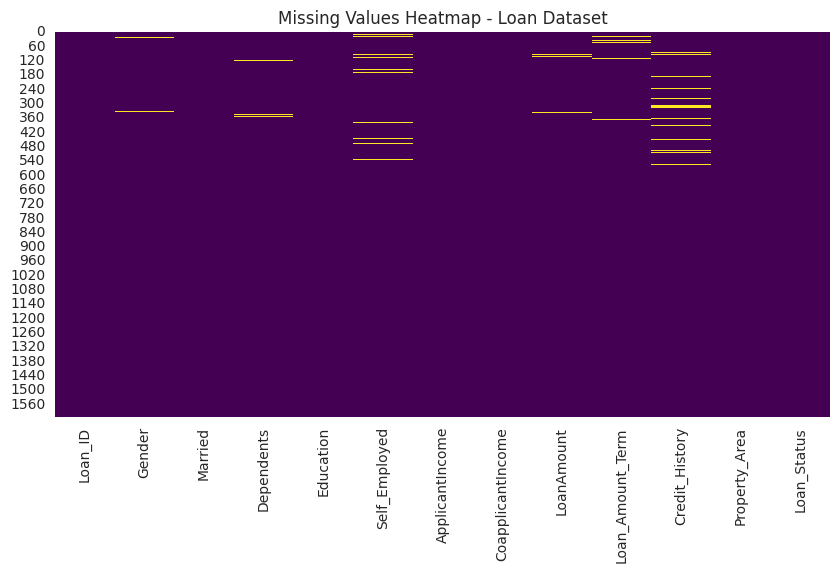

Duplicate rows: 0


In [6]:
plt.figure(figsize=(10,5))
sns.heatmap(loan.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap - Loan Dataset')
plt.show()

print("Duplicate rows:", loan.duplicated().sum())


## 1.3 Column-by-Column Analysis

We go through every column in the dataset, understand its distribution/values, and visualize it.


In [7]:
# Loan_ID - unique identifier
print("Unique Loan_IDs:", loan['Loan_ID'].nunique(), "out of", len(loan))
loan['Loan_ID'].head()


Unique Loan_IDs: 1538 out of 1614


0    LP001002
1    LP001003
2    LP001005
3    LP001006
4    LP001008
Name: Loan_ID, dtype: str

Gender
Male      980
Female    621
NaN        13
Name: count, dtype: int64


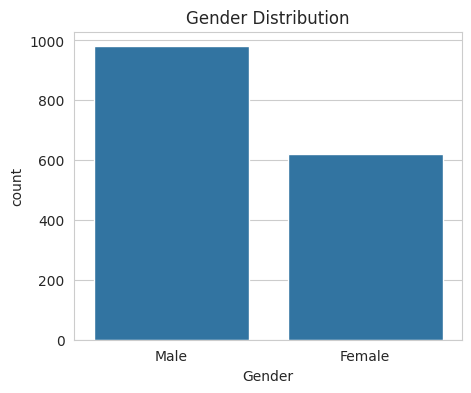

In [8]:
# Gender
print(loan['Gender'].value_counts(dropna=False))
plt.figure(figsize=(5,4))
sns.countplot(data=loan, x='Gender')
plt.title('Gender Distribution')
plt.show()


Married
Yes    925
No     686
NaN      3
Name: count, dtype: int64


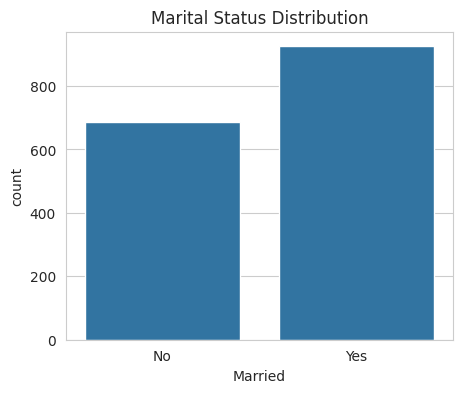

In [9]:
# Married
print(loan['Married'].value_counts(dropna=False))
plt.figure(figsize=(5,4))
sns.countplot(data=loan, x='Married')
plt.title('Marital Status Distribution')
plt.show()


Dependents
0      619
1      341
2      336
3+     303
NaN     15
Name: count, dtype: int64


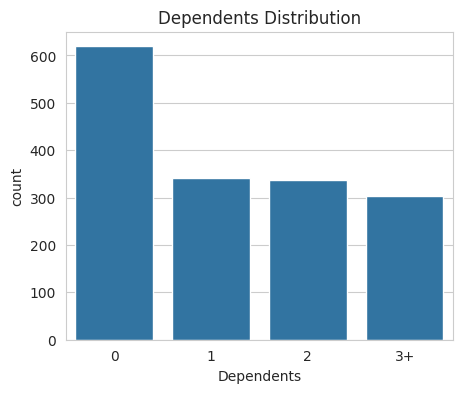

In [10]:
# Dependents
print(loan['Dependents'].value_counts(dropna=False))
plt.figure(figsize=(5,4))
sns.countplot(data=loan, x='Dependents', order=sorted(loan['Dependents'].dropna().unique()))
plt.title('Dependents Distribution')
plt.show()


Education
Graduate        952
Not Graduate    662
Name: count, dtype: int64


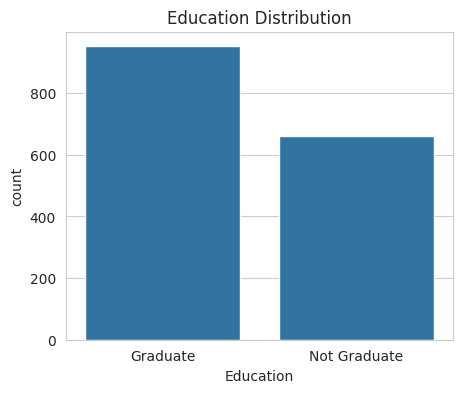

In [11]:
# Education
print(loan['Education'].value_counts(dropna=False))
plt.figure(figsize=(5,4))
sns.countplot(data=loan, x='Education')
plt.title('Education Distribution')
plt.show()


Self_Employed
No     999
Yes    583
NaN     32
Name: count, dtype: int64


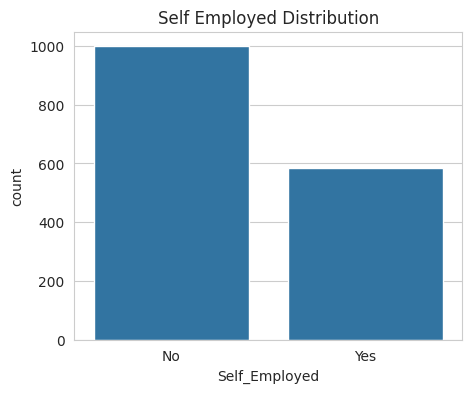

In [12]:
# Self_Employed
print(loan['Self_Employed'].value_counts(dropna=False))
plt.figure(figsize=(5,4))
sns.countplot(data=loan, x='Self_Employed')
plt.title('Self Employed Distribution')
plt.show()


count     1614.000000
mean      8746.304833
std       6249.885122
min        150.000000
25%       3675.250000
50%       7045.000000
75%      13251.000000
max      81000.000000
Name: ApplicantIncome, dtype: float64


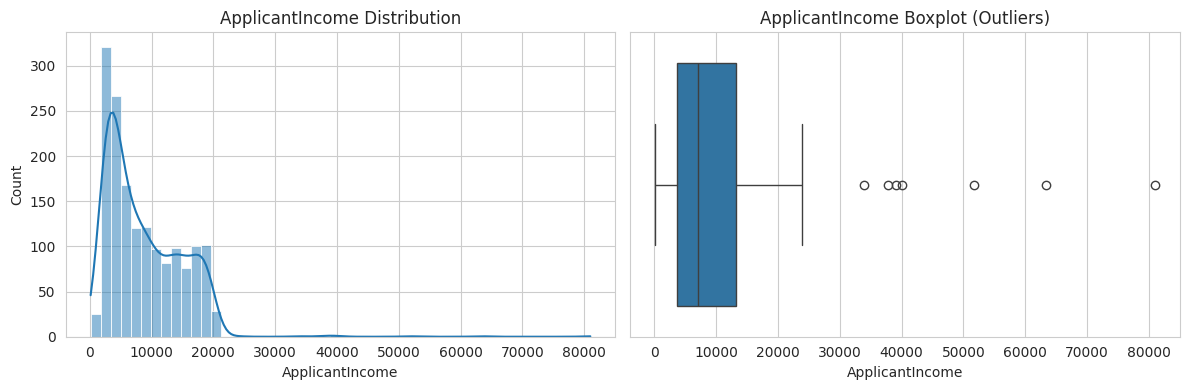

In [13]:
# ApplicantIncome
print(loan['ApplicantIncome'].describe())
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(loan['ApplicantIncome'], kde=True, ax=axes[0])
axes[0].set_title('ApplicantIncome Distribution')
sns.boxplot(x=loan['ApplicantIncome'], ax=axes[1])
axes[1].set_title('ApplicantIncome Boxplot (Outliers)')
plt.tight_layout()
plt.show()


count     1614.000000
mean      3658.722999
std       3291.745935
min          0.000000
25%        986.250000
50%       2941.500000
75%       5893.000000
max      41667.000000
Name: CoapplicantIncome, dtype: float64


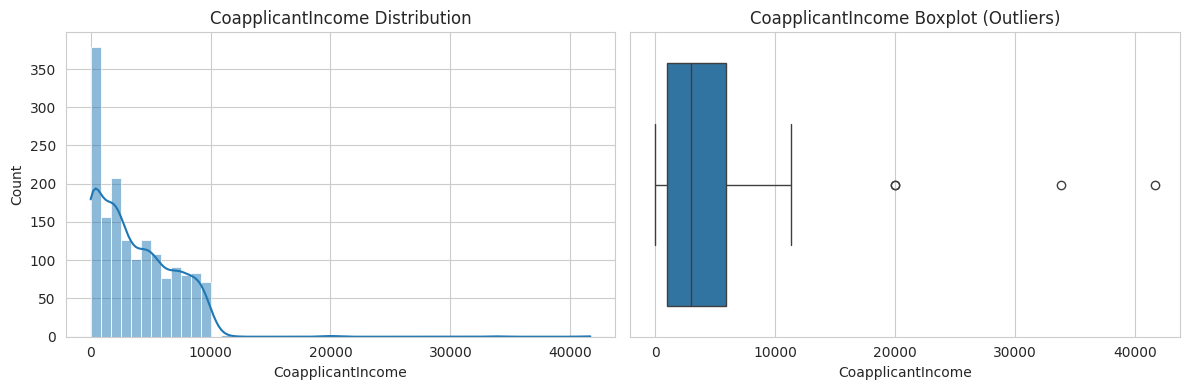

In [14]:
# CoapplicantIncome
print(loan['CoapplicantIncome'].describe())
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(loan['CoapplicantIncome'], kde=True, ax=axes[0])
axes[0].set_title('CoapplicantIncome Distribution')
sns.boxplot(x=loan['CoapplicantIncome'], ax=axes[1])
axes[1].set_title('CoapplicantIncome Boxplot (Outliers)')
plt.tight_layout()
plt.show()


count    1592.000000
mean      218.846734
std       133.623293
min         9.000000
25%       112.000000
50%       180.000000
75%       324.000000
max       700.000000
Name: LoanAmount, dtype: float64


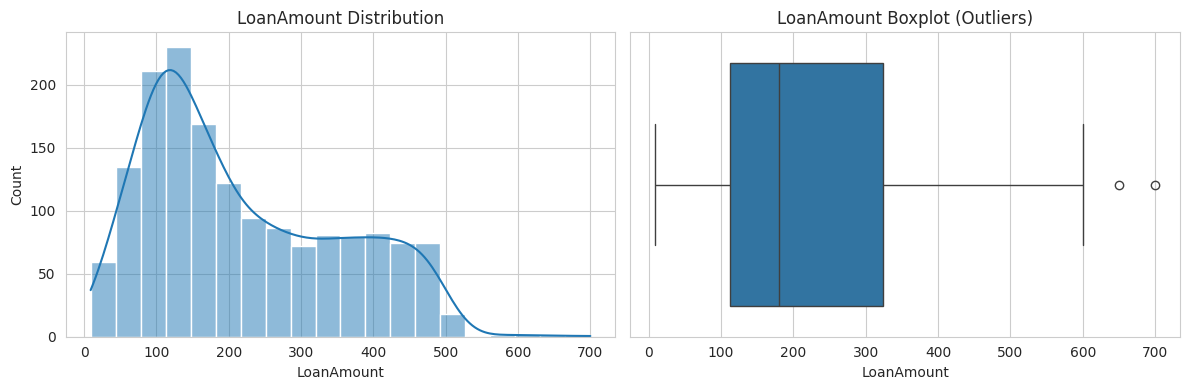

In [15]:
# LoanAmount
print(loan['LoanAmount'].describe())
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(loan['LoanAmount'].dropna(), kde=True, ax=axes[0])
axes[0].set_title('LoanAmount Distribution')
sns.boxplot(x=loan['LoanAmount'].dropna(), ax=axes[1])
axes[1].set_title('LoanAmount Boxplot (Outliers)')
plt.tight_layout()
plt.show()


Loan_Amount_Term
360.0    845
180.0    384
240.0    331
480.0     15
NaN       14
300.0     13
84.0       4
120.0      3
60.0       2
36.0       2
12.0       1
Name: count, dtype: int64


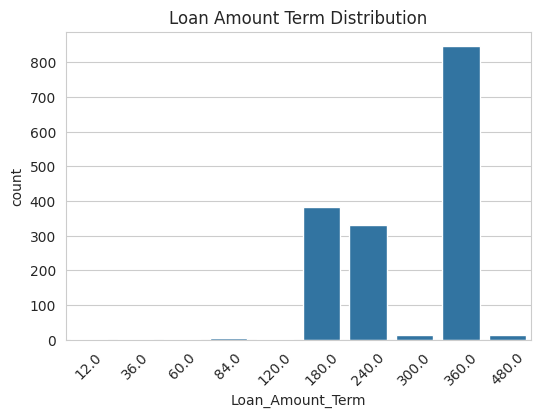

In [16]:
# Loan_Amount_Term
print(loan['Loan_Amount_Term'].value_counts(dropna=False))
plt.figure(figsize=(6,4))
sns.countplot(data=loan, x='Loan_Amount_Term')
plt.title('Loan Amount Term Distribution')
plt.xticks(rotation=45)
plt.show()


Credit_History
1.0    994
0.0    570
NaN     50
Name: count, dtype: int64


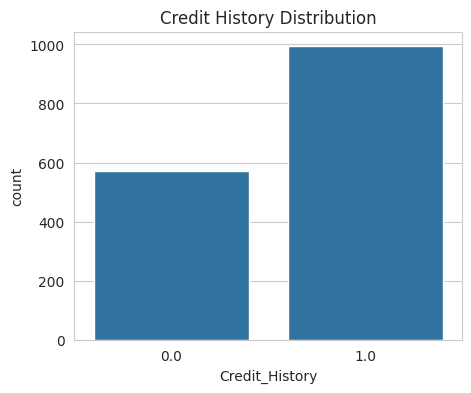

In [17]:
# Credit_History
print(loan['Credit_History'].value_counts(dropna=False))
plt.figure(figsize=(5,4))
sns.countplot(data=loan, x='Credit_History')
plt.title('Credit History Distribution')
plt.show()


Property_Area
Urban        549
Semiurban    545
Rural        520
Name: count, dtype: int64


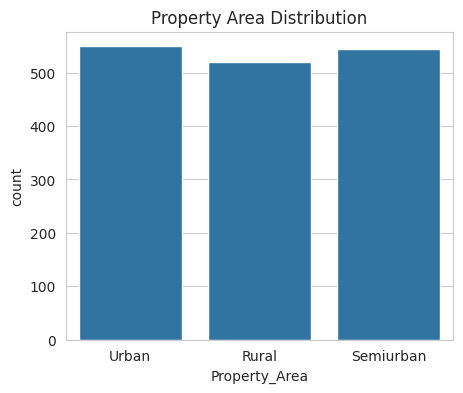

In [18]:
# Property_Area
print(loan['Property_Area'].value_counts(dropna=False))
plt.figure(figsize=(5,4))
sns.countplot(data=loan, x='Property_Area')
plt.title('Property Area Distribution')
plt.show()


Loan_Status
Y    915
N    699
Name: count, dtype: int64


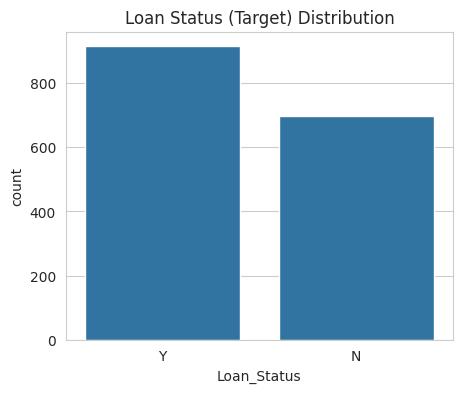

In [19]:
# Loan_Status (target variable)
print(loan['Loan_Status'].value_counts(dropna=False))
plt.figure(figsize=(5,4))
sns.countplot(data=loan, x='Loan_Status')
plt.title('Loan Status (Target) Distribution')
plt.show()


## 1.4 Bivariate Analysis (relationship with target `Loan_Status`)

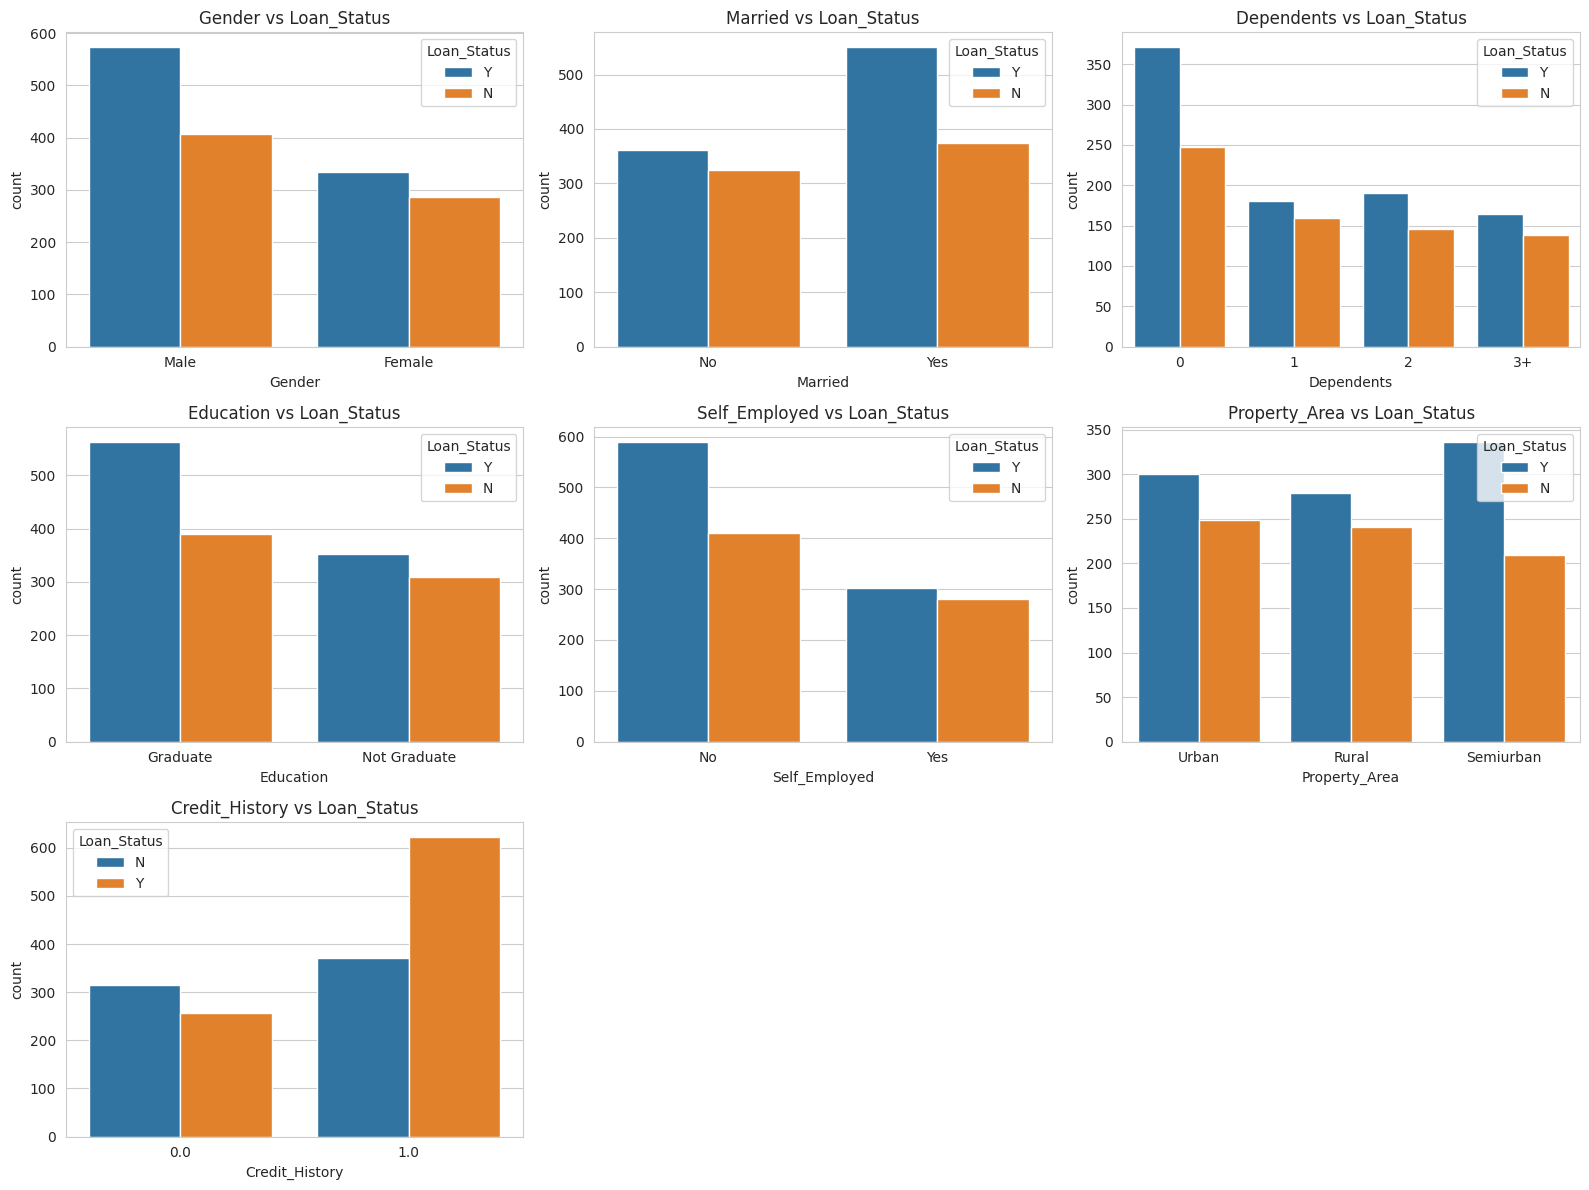

In [20]:
cat_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Credit_History']
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    sns.countplot(data=loan, x=col, hue='Loan_Status', ax=axes[i])
    axes[i].set_title(f'{col} vs Loan_Status')
for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


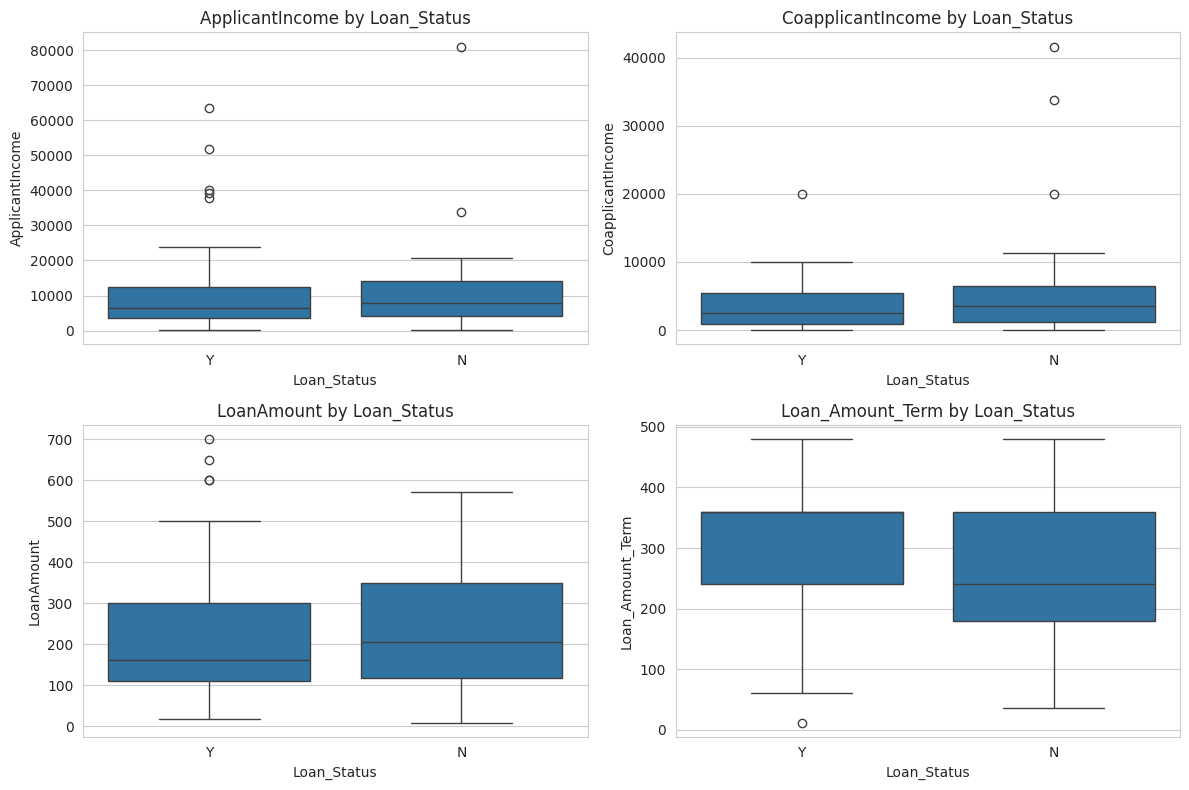

In [21]:
num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(data=loan, x='Loan_Status', y=col, ax=axes[i])
    axes[i].set_title(f'{col} by Loan_Status')
plt.tight_layout()
plt.show()


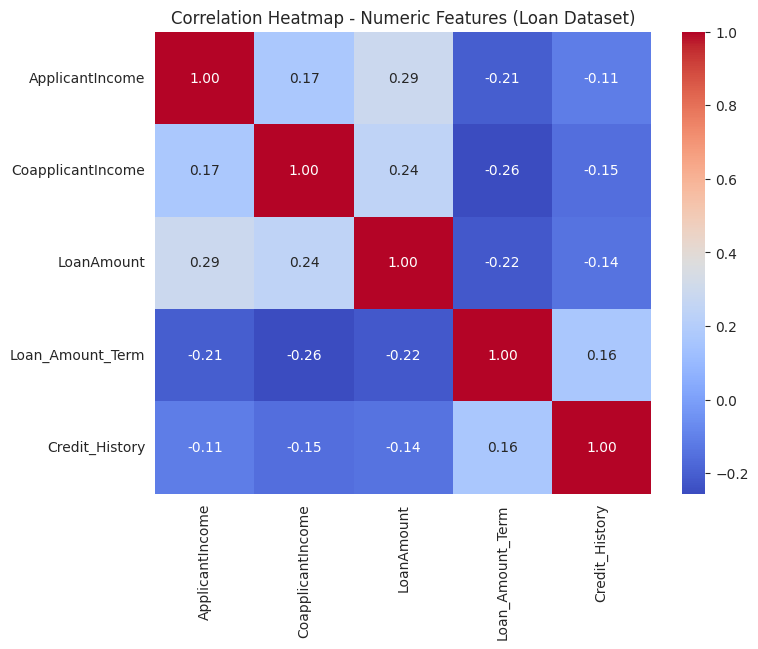

In [22]:
plt.figure(figsize=(8,6))
corr = loan[['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term','Credit_History']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - Numeric Features (Loan Dataset)')
plt.show()


## 1.5 Data Cleaning

Cleaning steps performed:
1. **Gender, Married, Dependents, Self_Employed, Credit_History** — fill missing values with the **mode** (most frequent category), since these are categorical/binary columns with relatively few missing values.
2. **LoanAmount** — fill missing values with the **median** (robust to the right-skew/outliers seen in the boxplot).
3. **Loan_Amount_Term** — fill missing values with the **mode** (360 is overwhelmingly the most common term).
4. **Dependents** — clean `'3+'` category into a numeric-friendly label and keep as category (or convert to numeric with 3+ capped at 3).
5. Verify no missing values remain and no duplicate rows exist.


In [23]:
loan_clean = loan.copy()

# 1. Categorical columns -> fill with mode
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']:
    mode_val = loan_clean[col].mode()[0]
    loan_clean[col] = loan_clean[col].fillna(mode_val)

# 2. LoanAmount -> fill with median
loan_clean['LoanAmount'] = loan_clean['LoanAmount'].fillna(loan_clean['LoanAmount'].median())

# 3. Loan_Amount_Term -> fill with mode
loan_clean['Loan_Amount_Term'] = loan_clean['Loan_Amount_Term'].fillna(loan_clean['Loan_Amount_Term'].mode()[0])

# 4. Clean Dependents column: '3+' -> 3, convert to numeric
loan_clean['Dependents'] = loan_clean['Dependents'].replace('3+', '3').astype(int)

# 5. Credit_History -> convert to int category (0/1)
loan_clean['Credit_History'] = loan_clean['Credit_History'].astype(int)

print("Missing values after cleaning:")
print(loan_clean.isnull().sum())
print("\nDuplicate rows:", loan_clean.duplicated().sum())


Missing values after cleaning:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

Duplicate rows: 0


In [24]:
# Outlier handling: cap extreme ApplicantIncome / CoapplicantIncome / LoanAmount using IQR capping
for col in ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']:
    Q1 = loan_clean[col].quantile(0.25)
    Q3 = loan_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((loan_clean[col] < lower) | (loan_clean[col] > upper)).sum()
    print(f"{col}: {n_outliers} outliers -> capped to [{lower:.1f}, {upper:.1f}]")
    loan_clean[col] = loan_clean[col].clip(lower, upper)


ApplicantIncome: 7 outliers -> capped to [-10688.4, 27614.6]
CoapplicantIncome: 4 outliers -> capped to [-6373.9, 13253.1]
LoanAmount: 2 outliers -> capped to [-203.0, 637.0]


In [25]:
loan_clean.info()
loan_clean.head()


<class 'pandas.DataFrame'>
RangeIndex: 1614 entries, 0 to 1613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            1614 non-null   str    
 1   Gender             1614 non-null   str    
 2   Married            1614 non-null   str    
 3   Dependents         1614 non-null   int64  
 4   Education          1614 non-null   str    
 5   Self_Employed      1614 non-null   str    
 6   ApplicantIncome    1614 non-null   float64
 7   CoapplicantIncome  1614 non-null   float64
 8   LoanAmount         1614 non-null   float64
 9   Loan_Amount_Term   1614 non-null   float64
 10  Credit_History     1614 non-null   int64  
 11  Property_Area      1614 non-null   str    
 12  Loan_Status        1614 non-null   str    
dtypes: float64(4), int64(2), str(7)
memory usage: 164.1 KB


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849.0,0.0,180.0,360.0,1,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583.0,1508.0,128.0,360.0,1,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000.0,0.0,66.0,360.0,1,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583.0,2358.0,120.0,360.0,1,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000.0,0.0,141.0,360.0,1,Urban,Y


In [26]:
loan_clean.to_csv('data/loan_train_cleaned.csv', index=False)
print("Saved cleaned Loan dataset -> data/loan_train_cleaned.csv")


Saved cleaned Loan dataset -> data/loan_train_cleaned.csv


---
# 2. Adult Census Income Dataset

**File:** `adult.csv`

**Columns:** age, workclass, fnlwgt, education, educational-num, marital-status, occupation, relationship, race, gender, capital-gain, capital-loss, hours-per-week, native-country, income

## 2.1 Load the Data


In [27]:
adult = pd.read_csv('data/adult.csv')
print("Shape:", adult.shape)
adult.head()


Shape: (48842, 15)


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [28]:
adult.info()


<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              48842 non-null  int64
 1   workclass        48842 non-null  str  
 2   fnlwgt           48842 non-null  int64
 3   education        48842 non-null  str  
 4   educational-num  48842 non-null  int64
 5   marital-status   48842 non-null  str  
 6   occupation       48842 non-null  str  
 7   relationship     48842 non-null  str  
 8   race             48842 non-null  str  
 9   gender           48842 non-null  str  
 10  capital-gain     48842 non-null  int64
 11  capital-loss     48842 non-null  int64
 12  hours-per-week   48842 non-null  int64
 13  native-country   48842 non-null  str  
 14  income           48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB


In [29]:
adult.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,48842.0,NaN,NaN,NaN,38.643585,13.71051,17.0,28.0,37.0,48.0,90.0
workclass,48842,9,Private,33906,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fnlwgt,48842.0,NaN,NaN,NaN,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
education,48842,16,HS-grad,15784,NaN,NaN,NaN,NaN,NaN,NaN,NaN
educational-num,48842.0,NaN,NaN,NaN,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
marital-status,48842,7,Married-civ-spouse,22379,NaN,NaN,NaN,NaN,NaN,NaN,NaN
occupation,48842,15,Prof-specialty,6172,NaN,NaN,NaN,NaN,NaN,NaN,NaN
relationship,48842,6,Husband,19716,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race,48842,5,White,41762,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,48842,2,Male,32650,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2.2 Missing Values & Duplicates

Note: In this dataset, missing values are often encoded as `'?'` rather than `NaN`. We first replace `'?'` with `NaN` so they are detected properly.


In [30]:
# Replace '?' with NaN across the whole dataframe
adult = adult.replace('?', np.nan)

missing = adult.isnull().sum()
missing_pct = (missing / len(adult) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_count', ascending=False)
missing_df


,missing_count,missing_pct
occupation,2809,5.75
workclass,2799,5.73
native-country,857,1.75


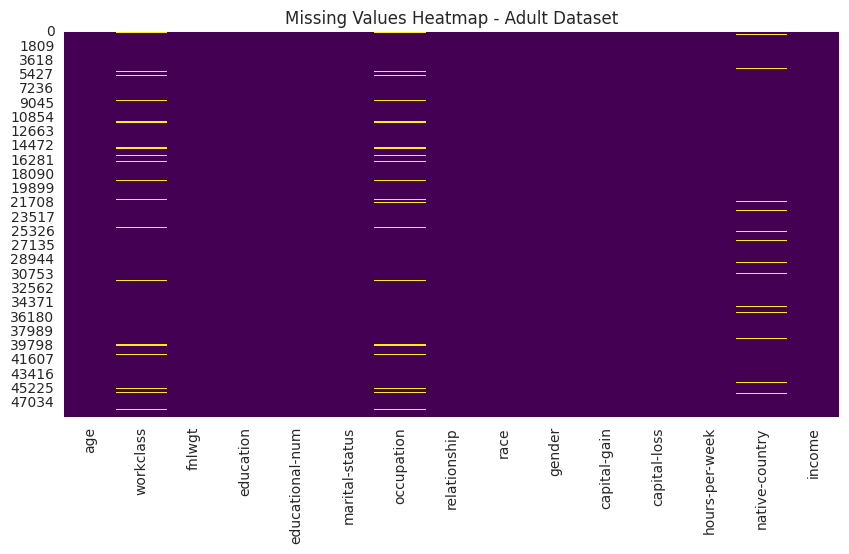

Duplicate rows: 52


In [31]:
plt.figure(figsize=(10,5))
sns.heatmap(adult.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap - Adult Dataset')
plt.show()

print("Duplicate rows:", adult.duplicated().sum())


## 2.3 Column-by-Column Analysis

count    48842.000000
mean        38.643585
std         13.710510
min         17.000000
25%         28.000000
50%         37.000000
75%         48.000000
max         90.000000
Name: age, dtype: float64


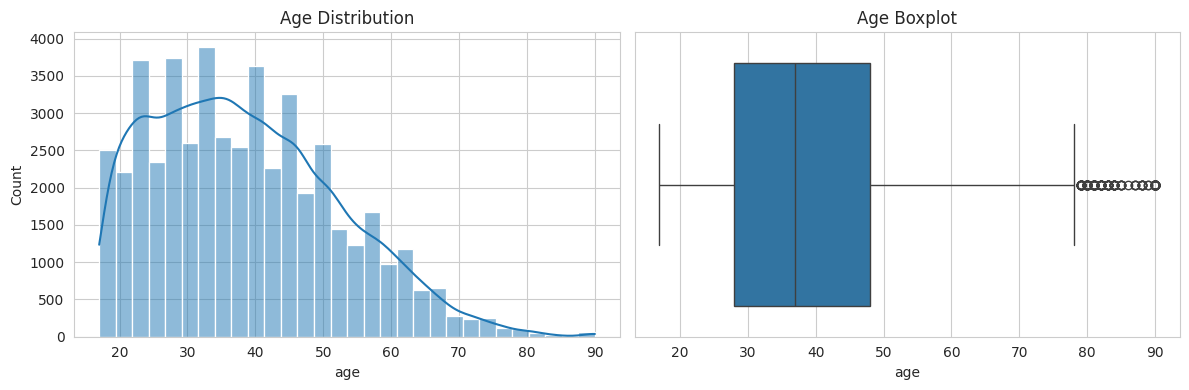

In [32]:
# age
print(adult['age'].describe())
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(adult['age'], kde=True, bins=30, ax=axes[0])
axes[0].set_title('Age Distribution')
sns.boxplot(x=adult['age'], ax=axes[1])
axes[1].set_title('Age Boxplot')
plt.tight_layout()
plt.show()


workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
NaN                  2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64


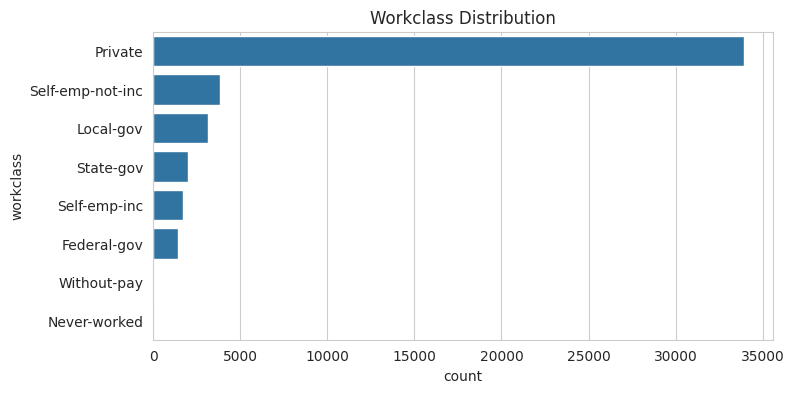

In [33]:
# workclass
print(adult['workclass'].value_counts(dropna=False))
plt.figure(figsize=(8,4))
sns.countplot(data=adult, y='workclass', order=adult['workclass'].value_counts().index)
plt.title('Workclass Distribution')
plt.show()


count    4.884200e+04
mean     1.896641e+05
std      1.056040e+05
min      1.228500e+04
25%      1.175505e+05
50%      1.781445e+05
75%      2.376420e+05
max      1.490400e+06
Name: fnlwgt, dtype: float64


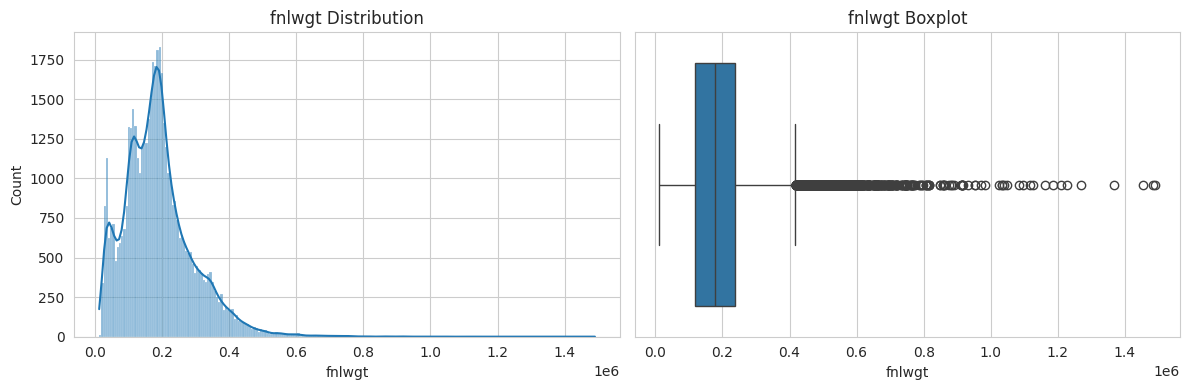

In [34]:
# fnlwgt (final sampling weight - a numeric column with wide range)
print(adult['fnlwgt'].describe())
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(adult['fnlwgt'], kde=True, ax=axes[0])
axes[0].set_title('fnlwgt Distribution')
sns.boxplot(x=adult['fnlwgt'], ax=axes[1])
axes[1].set_title('fnlwgt Boxplot')
plt.tight_layout()
plt.show()


education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64


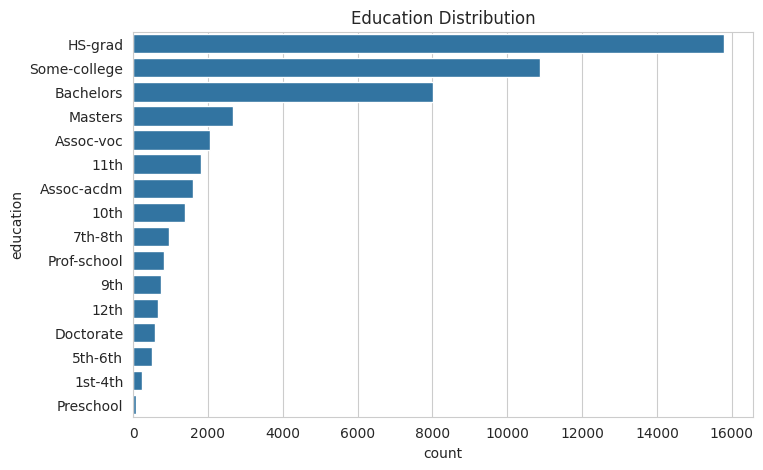

In [35]:
# education
print(adult['education'].value_counts(dropna=False))
plt.figure(figsize=(8,5))
sns.countplot(data=adult, y='education', order=adult['education'].value_counts().index)
plt.title('Education Distribution')
plt.show()


count    48842.000000
mean        10.078089
std          2.570973
min          1.000000
25%          9.000000
50%         10.000000
75%         12.000000
max         16.000000
Name: educational-num, dtype: float64


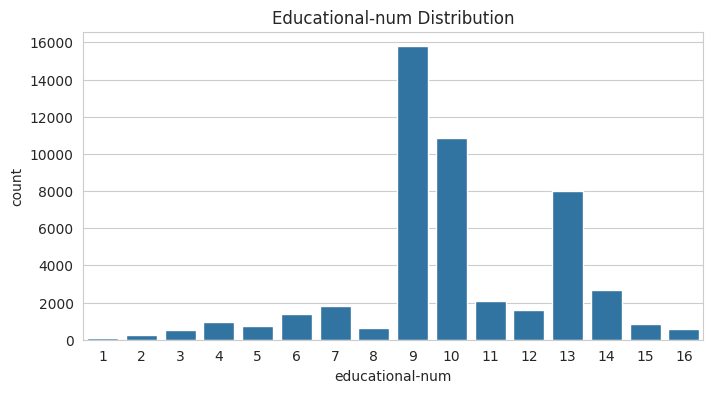

In [36]:
# educational-num
print(adult['educational-num'].describe())
plt.figure(figsize=(8,4))
sns.countplot(data=adult, x='educational-num')
plt.title('Educational-num Distribution')
plt.show()


In [37]:
# educational-num vs education sanity check (should be 1:1 mapping)
adult.groupby('education')['educational-num'].unique()


education
10th             [6]
11th             [7]
12th             [8]
1st-4th          [2]
5th-6th          [3]
7th-8th          [4]
9th              [5]
Assoc-acdm      [12]
Assoc-voc       [11]
Bachelors       [13]
Doctorate       [16]
HS-grad          [9]
Masters         [14]
Preschool        [1]
Prof-school     [15]
Some-college    [10]
Name: educational-num, dtype: object

marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64


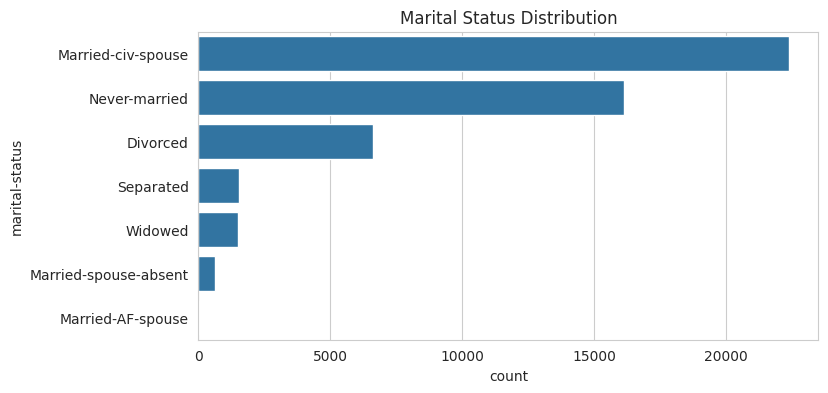

In [38]:
# marital-status
print(adult['marital-status'].value_counts(dropna=False))
plt.figure(figsize=(8,4))
sns.countplot(data=adult, y='marital-status', order=adult['marital-status'].value_counts().index)
plt.title('Marital Status Distribution')
plt.show()


occupation
Prof-specialty       6172
Craft-repair         6112
Exec-managerial      6086
Adm-clerical         5611
Sales                5504
Other-service        4923
Machine-op-inspct    3022
NaN                  2809
Transport-moving     2355
Handlers-cleaners    2072
Farming-fishing      1490
Tech-support         1446
Protective-serv       983
Priv-house-serv       242
Armed-Forces           15
Name: count, dtype: int64


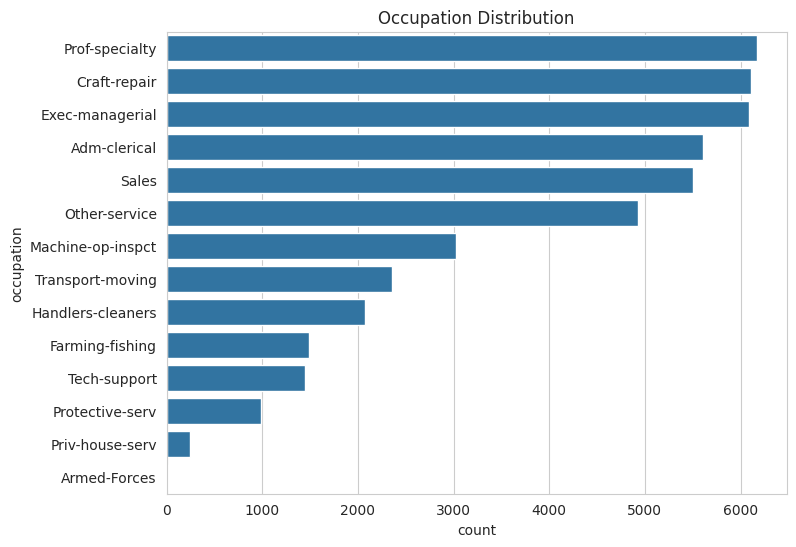

In [39]:
# occupation
print(adult['occupation'].value_counts(dropna=False))
plt.figure(figsize=(8,6))
sns.countplot(data=adult, y='occupation', order=adult['occupation'].value_counts().index)
plt.title('Occupation Distribution')
plt.show()


relationship
Husband           19716
Not-in-family     12583
Own-child          7581
Unmarried          5125
Wife               2331
Other-relative     1506
Name: count, dtype: int64


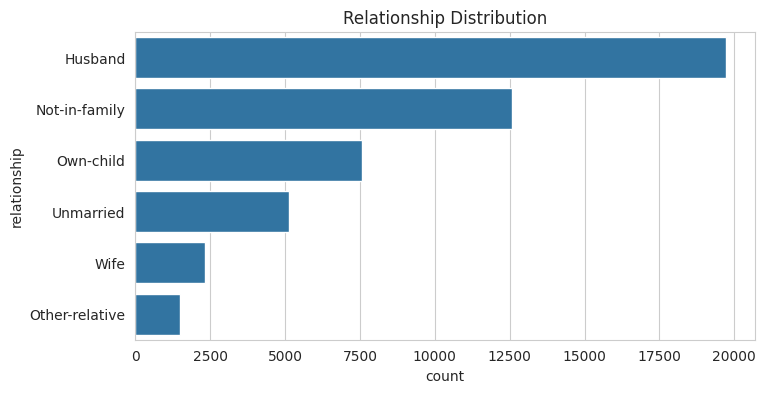

In [40]:
# relationship
print(adult['relationship'].value_counts(dropna=False))
plt.figure(figsize=(8,4))
sns.countplot(data=adult, y='relationship', order=adult['relationship'].value_counts().index)
plt.title('Relationship Distribution')
plt.show()


race
White                 41762
Black                  4685
Asian-Pac-Islander     1519
Amer-Indian-Eskimo      470
Other                   406
Name: count, dtype: int64


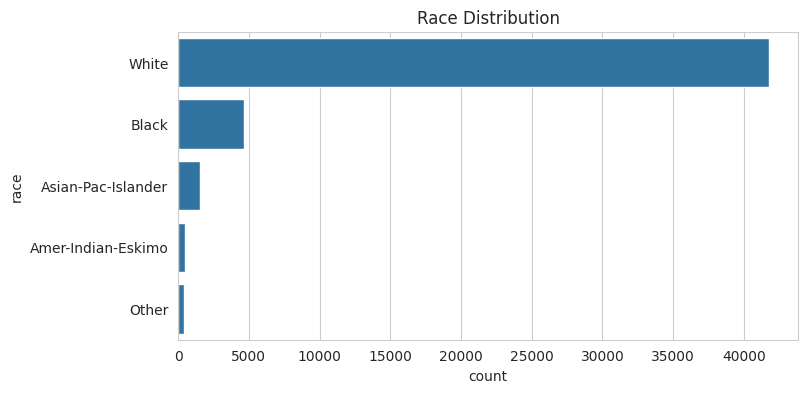

In [41]:
# race
print(adult['race'].value_counts(dropna=False))
plt.figure(figsize=(8,4))
sns.countplot(data=adult, y='race', order=adult['race'].value_counts().index)
plt.title('Race Distribution')
plt.show()


gender
Male      32650
Female    16192
Name: count, dtype: int64


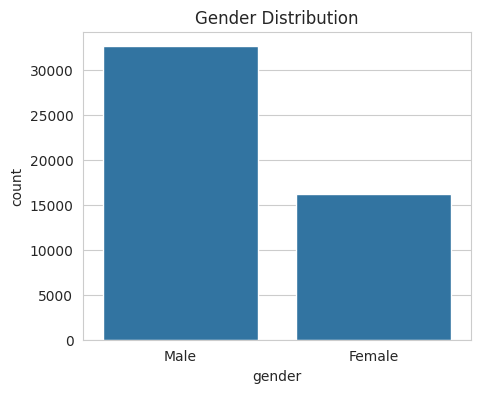

In [42]:
# gender
print(adult['gender'].value_counts(dropna=False))
plt.figure(figsize=(5,4))
sns.countplot(data=adult, x='gender')
plt.title('Gender Distribution')
plt.show()


count    48842.000000
mean      1079.067626
std       7452.019058
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      99999.000000
Name: capital-gain, dtype: float64
Zero values: 44807 out of 48842


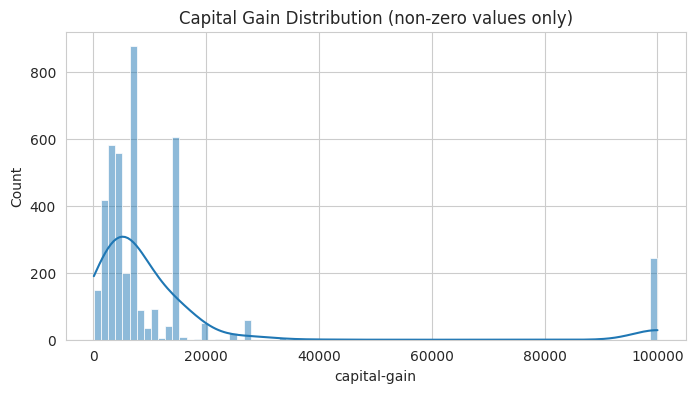

In [43]:
# capital-gain
print(adult['capital-gain'].describe())
print("Zero values:", (adult['capital-gain'] == 0).sum(), "out of", len(adult))
plt.figure(figsize=(8,4))
sns.histplot(adult[adult['capital-gain'] > 0]['capital-gain'], kde=True)
plt.title('Capital Gain Distribution (non-zero values only)')
plt.show()


count    48842.000000
mean        87.502314
std        403.004552
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       4356.000000
Name: capital-loss, dtype: float64
Zero values: 46560 out of 48842


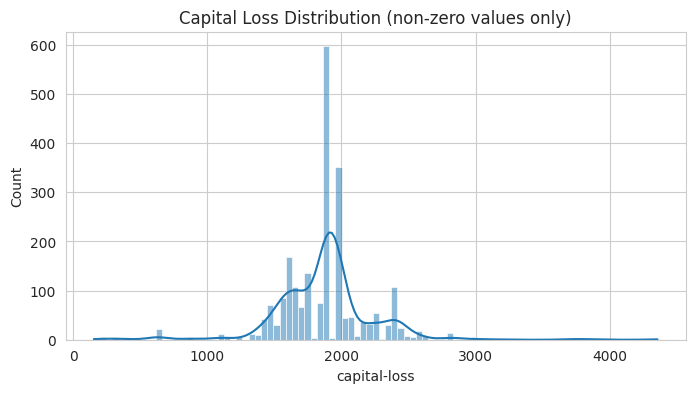

In [44]:
# capital-loss
print(adult['capital-loss'].describe())
print("Zero values:", (adult['capital-loss'] == 0).sum(), "out of", len(adult))
plt.figure(figsize=(8,4))
sns.histplot(adult[adult['capital-loss'] > 0]['capital-loss'], kde=True)
plt.title('Capital Loss Distribution (non-zero values only)')
plt.show()


count    48842.000000
mean        40.422382
std         12.391444
min          1.000000
25%         40.000000
50%         40.000000
75%         45.000000
max         99.000000
Name: hours-per-week, dtype: float64


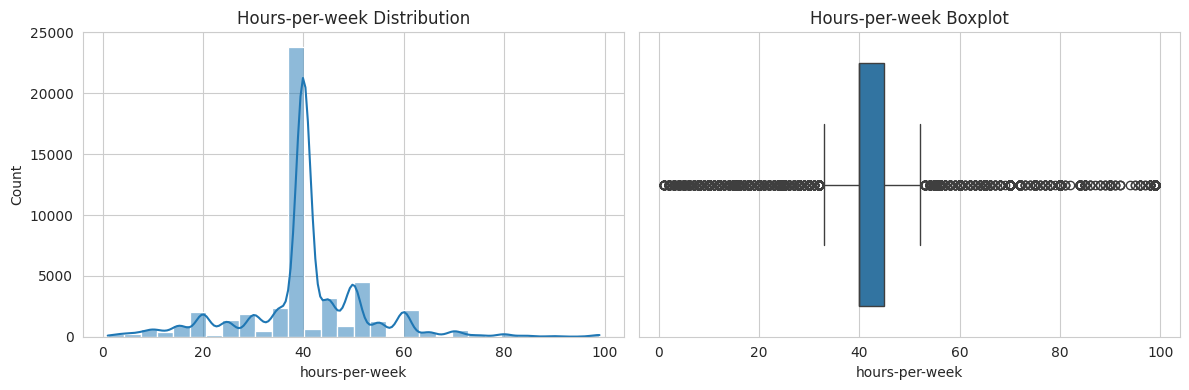

In [45]:
# hours-per-week
print(adult['hours-per-week'].describe())
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(adult['hours-per-week'], kde=True, bins=30, ax=axes[0])
axes[0].set_title('Hours-per-week Distribution')
sns.boxplot(x=adult['hours-per-week'], ax=axes[1])
axes[1].set_title('Hours-per-week Boxplot')
plt.tight_layout()
plt.show()


native-country
United-States    43832
Mexico             951
NaN                857
Philippines        295
Germany            206
Puerto-Rico        184
Canada             182
El-Salvador        155
India              151
Cuba               138
England            127
China              122
South              115
Jamaica            106
Italy              105
Name: count, dtype: int64


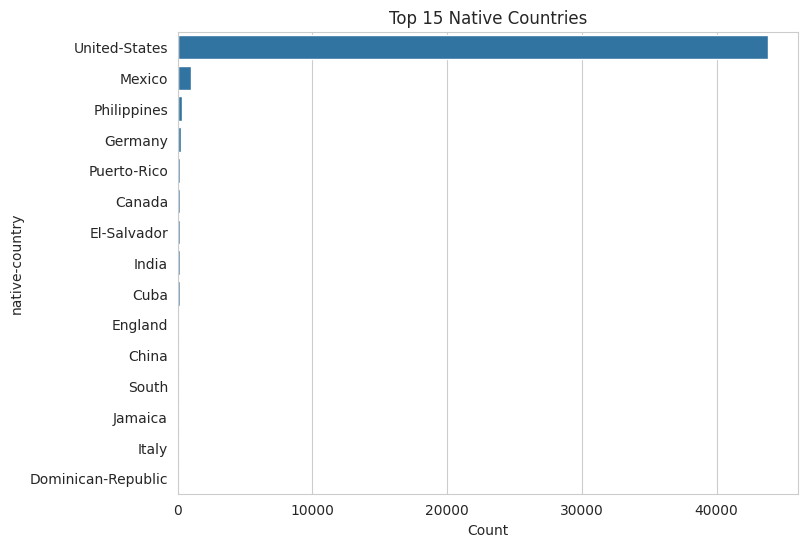

In [46]:
# native-country
print(adult['native-country'].value_counts(dropna=False).head(15))
plt.figure(figsize=(8,6))
top_countries = adult['native-country'].value_counts().head(15)
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title('Top 15 Native Countries')
plt.xlabel('Count')
plt.show()


income
<=50K    37155
>50K     11687
Name: count, dtype: int64


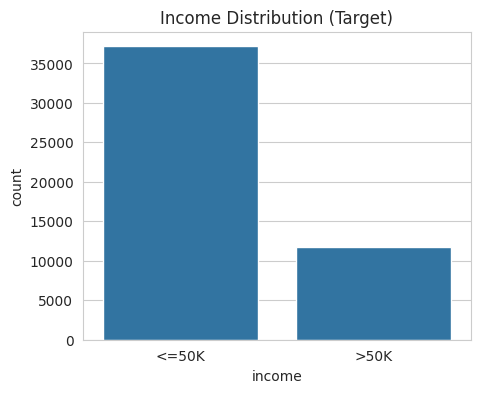

In [47]:
# income (target variable)
print(adult['income'].value_counts(dropna=False))
plt.figure(figsize=(5,4))
sns.countplot(data=adult, x='income')
plt.title('Income Distribution (Target)')
plt.show()


## 2.4 Bivariate Analysis (relationship with target `income`)

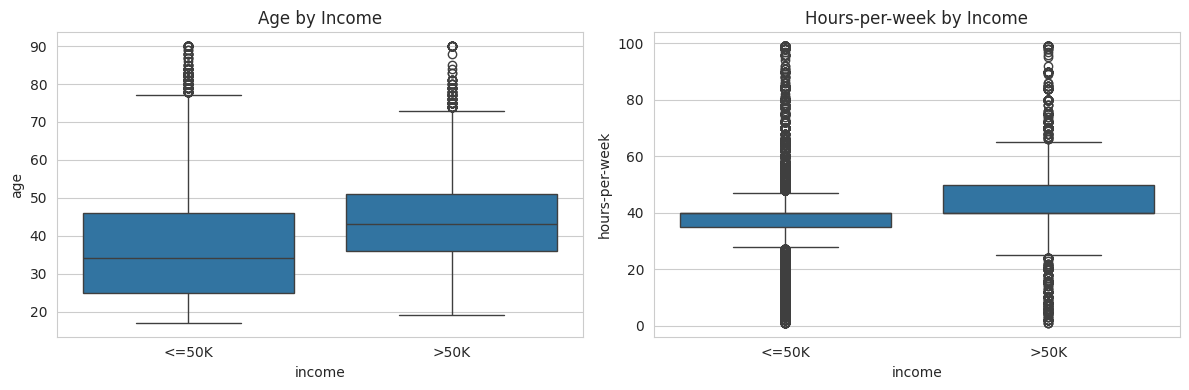

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.boxplot(data=adult, x='income', y='age', ax=axes[0])
axes[0].set_title('Age by Income')
sns.boxplot(data=adult, x='income', y='hours-per-week', ax=axes[1])
axes[1].set_title('Hours-per-week by Income')
plt.tight_layout()
plt.show()


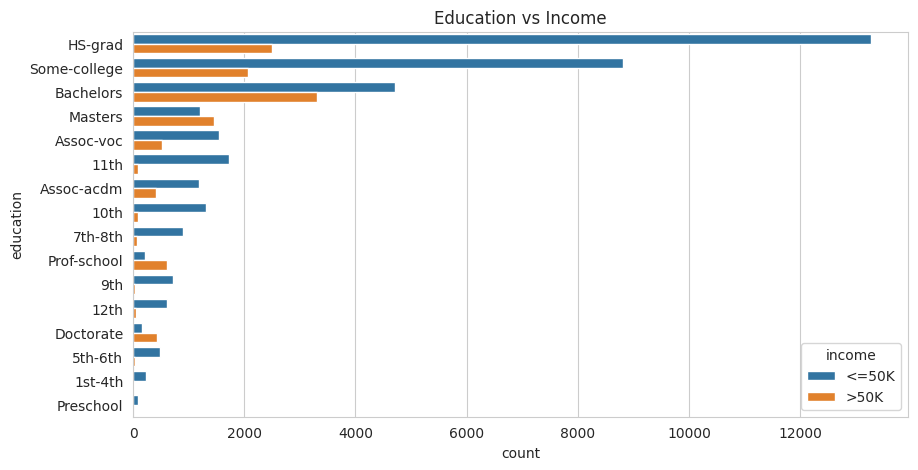

In [49]:
plt.figure(figsize=(10,5))
sns.countplot(data=adult, y='education', hue='income', order=adult['education'].value_counts().index)
plt.title('Education vs Income')
plt.show()


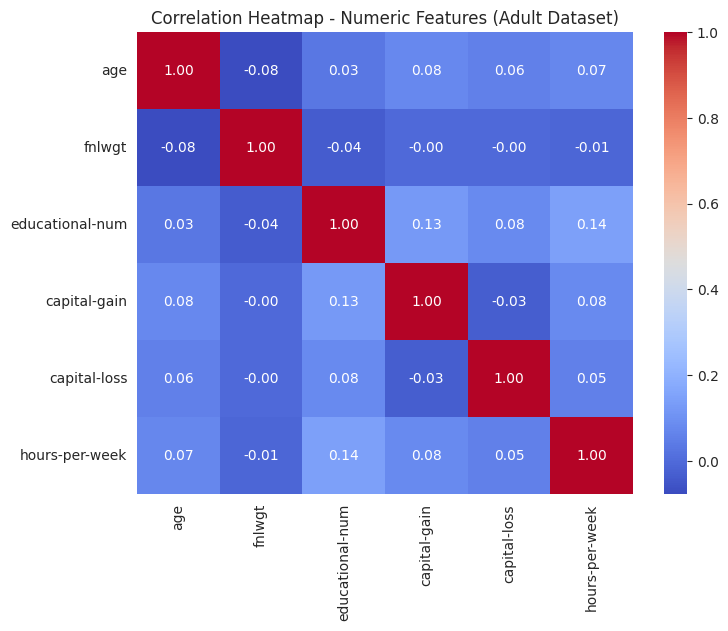

In [50]:
num_cols_adult = ['age','fnlwgt','educational-num','capital-gain','capital-loss','hours-per-week']
plt.figure(figsize=(8,6))
sns.heatmap(adult[num_cols_adult].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - Numeric Features (Adult Dataset)')
plt.show()


## 2.5 Data Cleaning

Cleaning steps performed:
1. Already replaced `'?'` with `NaN` above.
2. **workclass, occupation, native-country** — the only columns with missing values. Fill with the **mode** since they are categorical.
3. Drop **duplicate rows** if any.
4. Drop the redundant **education** column is kept (informative to read) but note `educational-num` is its numeric encoding — no column dropped, both retained for analysis.
5. Standardize text columns (strip whitespace).
6. Cap outliers in **capital-gain**, **capital-loss**, and **hours-per-week** conceptually noted (these are legitimate wide-range values, so we do NOT blindly cap them — instead we just document extreme values, since aggressive capping would distort the meaning of these income-related columns).


In [51]:
adult_clean = adult.copy()

# Strip whitespace from all string/object columns
obj_cols = adult_clean.select_dtypes(include='object').columns
for col in obj_cols:
    adult_clean[col] = adult_clean[col].str.strip()

# Fill missing categorical values with mode
for col in ['workclass', 'occupation', 'native-country']:
    mode_val = adult_clean[col].mode()[0]
    adult_clean[col] = adult_clean[col].fillna(mode_val)

# Drop exact duplicate rows
before = len(adult_clean)
adult_clean = adult_clean.drop_duplicates()
print(f"Dropped {before - len(adult_clean)} duplicate rows")

print("\nMissing values after cleaning:")
print(adult_clean.isnull().sum())


Dropped 53 duplicate rows

Missing values after cleaning:
age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64


In [52]:
adult_clean.info()
adult_clean.head()


<class 'pandas.DataFrame'>
Index: 48789 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              48789 non-null  int64
 1   workclass        48789 non-null  str  
 2   fnlwgt           48789 non-null  int64
 3   education        48789 non-null  str  
 4   educational-num  48789 non-null  int64
 5   marital-status   48789 non-null  str  
 6   occupation       48789 non-null  str  
 7   relationship     48789 non-null  str  
 8   race             48789 non-null  str  
 9   gender           48789 non-null  str  
 10  capital-gain     48789 non-null  int64
 11  capital-loss     48789 non-null  int64
 12  hours-per-week   48789 non-null  int64
 13  native-country   48789 non-null  str  
 14  income           48789 non-null  str  
dtypes: int64(6), str(9)
memory usage: 6.0 MB


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,Private,103497,Some-college,10,Never-married,Prof-specialty,Own-child,White,Female,0,0,30,United-States,<=50K


In [53]:
adult_clean.to_csv('data/adult_cleaned.csv', index=False)
print("Saved cleaned Adult dataset -> data/adult_cleaned.csv")


Saved cleaned Adult dataset -> data/adult_cleaned.csv


---
# 3. Hotel Booking Dataset

**File:** `hotel_booking.csv`

This is a large dataset with 32 columns covering booking details, guest info, and PII fields (name, email, phone, credit card).

## 3.1 Load the Data


In [54]:
hotel = pd.read_csv('data/hotel_booking.csv')
print("Shape:", hotel.shape)
hotel.head()


Shape: (119390, 36)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


In [55]:
hotel.info()


<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [56]:
hotel.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
hotel,119390,2,City Hotel,79330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_canceled,119390.0,NaN,NaN,NaN,0.370416,0.482918,0.0,0.0,0.0,1.0,1.0
lead_time,119390.0,NaN,NaN,NaN,104.011416,106.863097,0.0,18.0,69.0,160.0,737.0
arrival_date_year,119390.0,NaN,NaN,NaN,2016.156554,0.707476,2015.0,2016.0,2016.0,2017.0,2017.0
arrival_date_month,119390,12,August,13877,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_date_week_number,119390.0,NaN,NaN,NaN,27.165173,13.605138,1.0,16.0,28.0,38.0,53.0
arrival_date_day_of_month,119390.0,NaN,NaN,NaN,15.798241,8.780829,1.0,8.0,16.0,23.0,31.0
stays_in_weekend_nights,119390.0,NaN,NaN,NaN,0.927599,0.998613,0.0,0.0,1.0,2.0,19.0
stays_in_week_nights,119390.0,NaN,NaN,NaN,2.500302,1.908286,0.0,1.0,2.0,3.0,50.0
adults,119390.0,NaN,NaN,NaN,1.856403,0.579261,0.0,2.0,2.0,2.0,55.0


## 3.2 Missing Values & Duplicates

In [57]:
missing = hotel.isnull().sum()
missing_pct = (missing / len(hotel) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_count', ascending=False)
missing_df


,missing_count,missing_pct
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


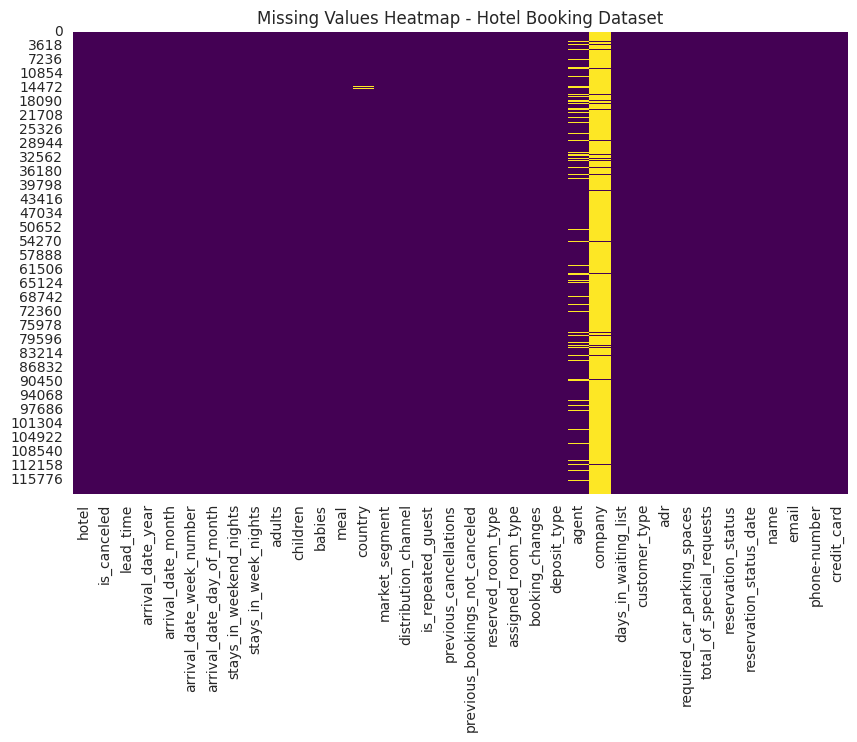

Duplicate rows: 0


In [58]:
plt.figure(figsize=(10,6))
sns.heatmap(hotel.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap - Hotel Booking Dataset')
plt.show()

print("Duplicate rows:", hotel.duplicated().sum())


## 3.3 Column-by-Column Analysis

Given the large number of columns (32), we group them logically for analysis: booking meta info, stay details, guest counts, channel/segment info, history/behaviour, financials, and PII fields.


hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64


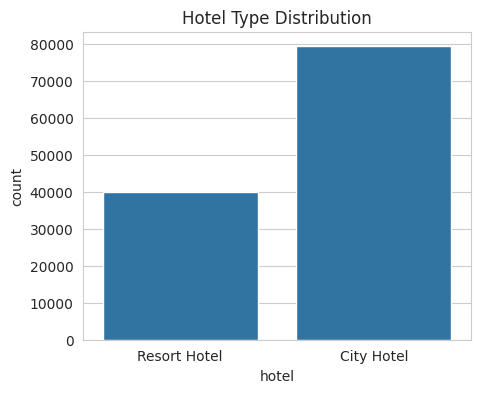

In [59]:
# hotel (type)
print(hotel['hotel'].value_counts(dropna=False))
plt.figure(figsize=(5,4))
sns.countplot(data=hotel, x='hotel')
plt.title('Hotel Type Distribution')
plt.show()


is_canceled
0    75166
1    44224
Name: count, dtype: int64


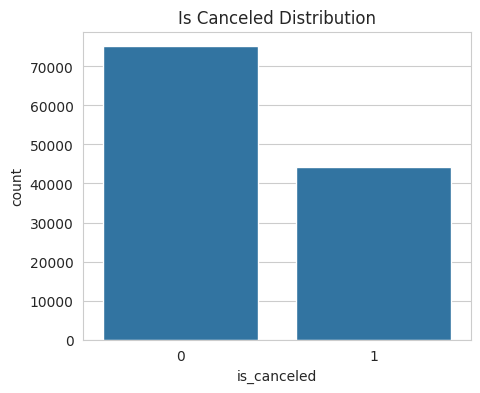

In [60]:
# is_canceled (target-like variable)
print(hotel['is_canceled'].value_counts(dropna=False))
plt.figure(figsize=(5,4))
sns.countplot(data=hotel, x='is_canceled')
plt.title('Is Canceled Distribution')
plt.show()


count    119390.000000
mean        104.011416
std         106.863097
min           0.000000
25%          18.000000
50%          69.000000
75%         160.000000
max         737.000000
Name: lead_time, dtype: float64


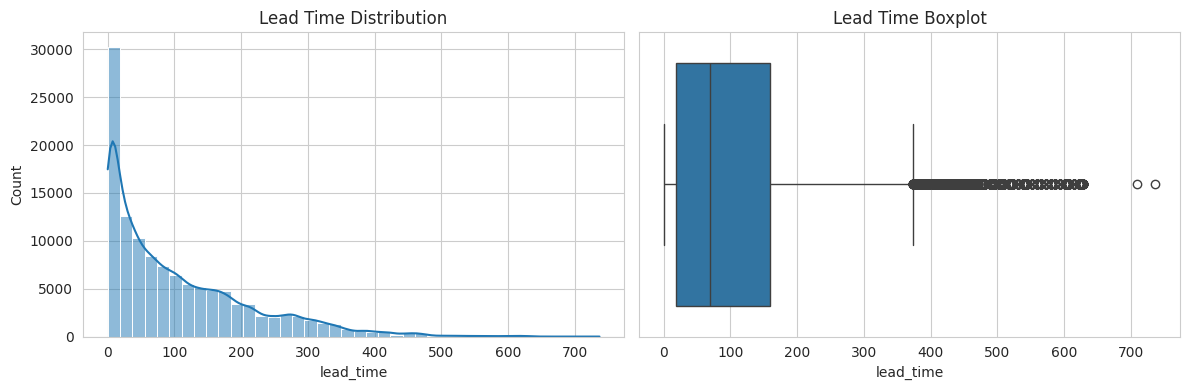

In [61]:
# lead_time
print(hotel['lead_time'].describe())
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(hotel['lead_time'], kde=True, bins=40, ax=axes[0])
axes[0].set_title('Lead Time Distribution')
sns.boxplot(x=hotel['lead_time'], ax=axes[1])
axes[1].set_title('Lead Time Boxplot')
plt.tight_layout()
plt.show()


arrival_date_year
2015    21996
2016    56707
2017    40687
Name: count, dtype: int64


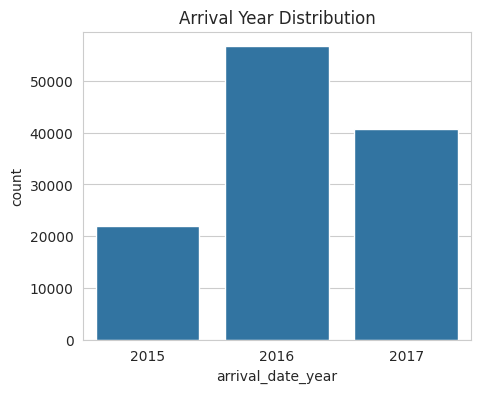

In [62]:
# arrival_date_year
print(hotel['arrival_date_year'].value_counts(dropna=False).sort_index())
plt.figure(figsize=(5,4))
sns.countplot(data=hotel, x='arrival_date_year')
plt.title('Arrival Year Distribution')
plt.show()


arrival_date_month
August       13877
July         12661
May          11791
October      11160
April        11089
June         10939
September    10508
March         9794
February      8068
November      6794
December      6780
January       5929
Name: count, dtype: int64


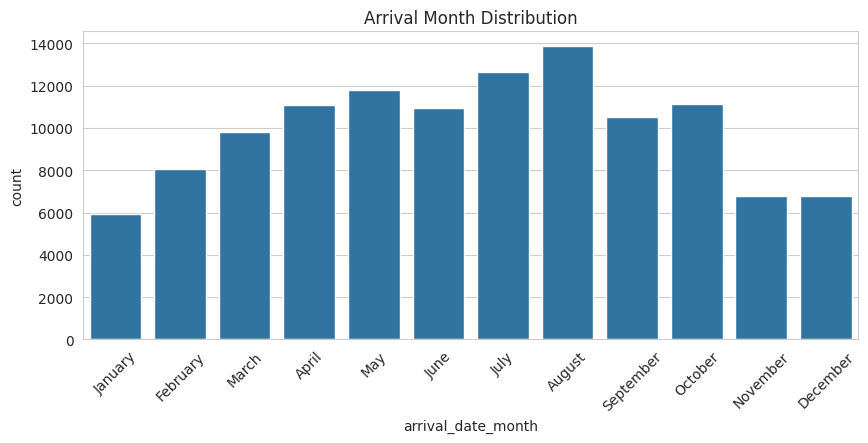

In [63]:
# arrival_date_month
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
print(hotel['arrival_date_month'].value_counts(dropna=False))
plt.figure(figsize=(10,4))
sns.countplot(data=hotel, x='arrival_date_month', order=month_order)
plt.title('Arrival Month Distribution')
plt.xticks(rotation=45)
plt.show()


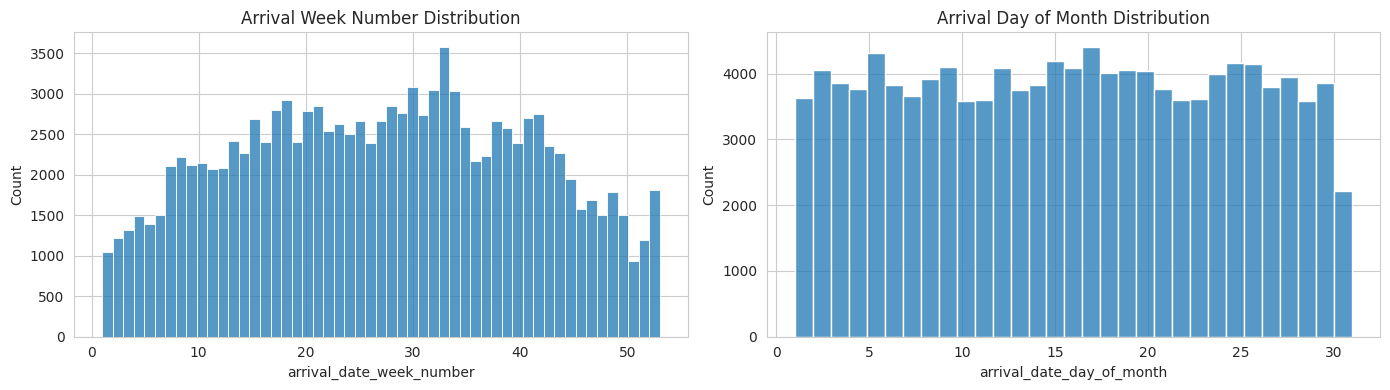

In [64]:
# arrival_date_week_number & arrival_date_day_of_month
fig, axes = plt.subplots(1, 2, figsize=(14,4))
sns.histplot(hotel['arrival_date_week_number'], bins=53, ax=axes[0])
axes[0].set_title('Arrival Week Number Distribution')
sns.histplot(hotel['arrival_date_day_of_month'], bins=31, ax=axes[1])
axes[1].set_title('Arrival Day of Month Distribution')
plt.tight_layout()
plt.show()


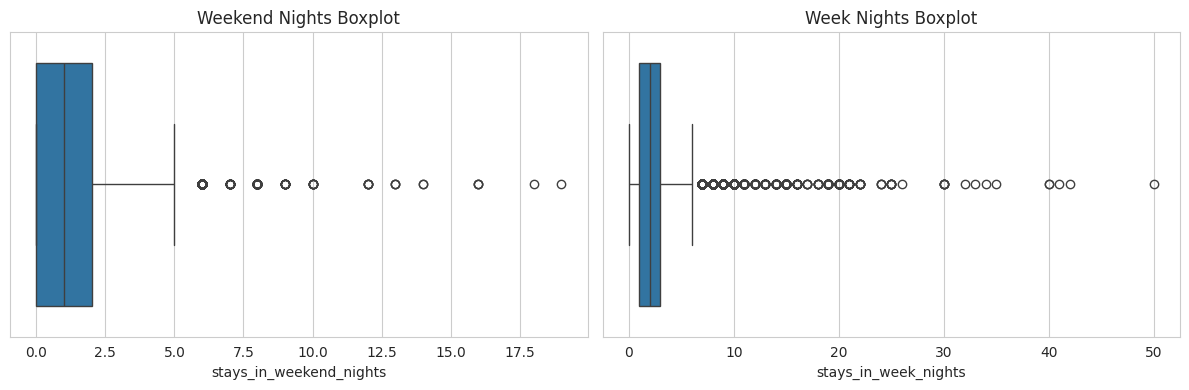

       stays_in_weekend_nights  stays_in_week_nights
count            119390.000000         119390.000000
mean                  0.927599              2.500302
std                   0.998613              1.908286
min                   0.000000              0.000000
25%                   0.000000              1.000000
50%                   1.000000              2.000000
75%                   2.000000              3.000000
max                  19.000000             50.000000


In [65]:
# stays_in_weekend_nights & stays_in_week_nights
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.boxplot(x=hotel['stays_in_weekend_nights'], ax=axes[0])
axes[0].set_title('Weekend Nights Boxplot')
sns.boxplot(x=hotel['stays_in_week_nights'], ax=axes[1])
axes[1].set_title('Week Nights Boxplot')
plt.tight_layout()
plt.show()
print(hotel[['stays_in_weekend_nights','stays_in_week_nights']].describe())


count    119390.000000
mean          1.856403
std           0.579261
min           0.000000
25%           2.000000
50%           2.000000
75%           2.000000
max          55.000000
Name: adults, dtype: float64
count    119386.000000
mean          0.103890
std           0.398561
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          10.000000
Name: children, dtype: float64
count    119390.000000
mean          0.007949
std           0.097436
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          10.000000
Name: babies, dtype: float64


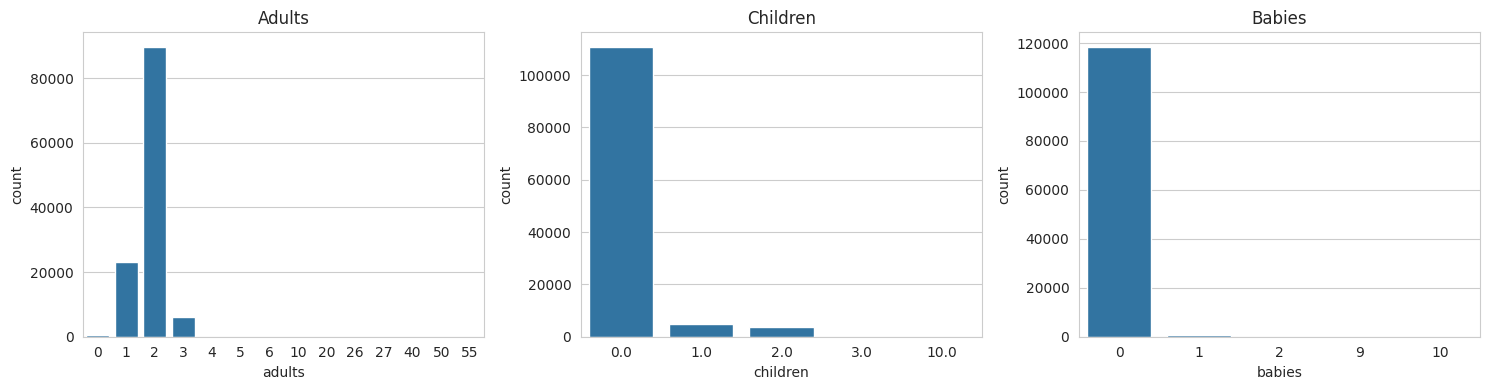

In [66]:
# adults, children, babies
print(hotel['adults'].describe())
print(hotel['children'].describe())
print(hotel['babies'].describe())

fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.countplot(x=hotel['adults'], ax=axes[0]); axes[0].set_title('Adults')
sns.countplot(x=hotel['children'], ax=axes[1]); axes[1].set_title('Children')
sns.countplot(x=hotel['babies'], ax=axes[2]); axes[2].set_title('Babies')
plt.tight_layout()
plt.show()


meal
BB           92310
HB           14463
SC           10650
Undefined     1169
FB             798
Name: count, dtype: int64


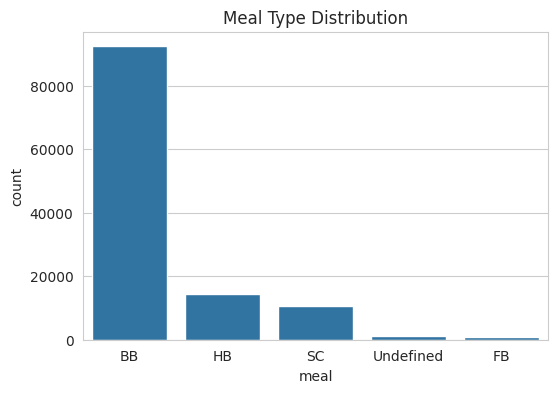

In [67]:
# meal
print(hotel['meal'].value_counts(dropna=False))
plt.figure(figsize=(6,4))
sns.countplot(data=hotel, x='meal', order=hotel['meal'].value_counts().index)
plt.title('Meal Type Distribution')
plt.show()


country
PRT    48590
GBR    12129
FRA    10415
ESP     8568
DEU     7287
ITA     3766
IRL     3375
BEL     2342
BRA     2224
NLD     2104
USA     2097
CHE     1730
CN      1279
AUT     1263
SWE     1024
Name: count, dtype: int64


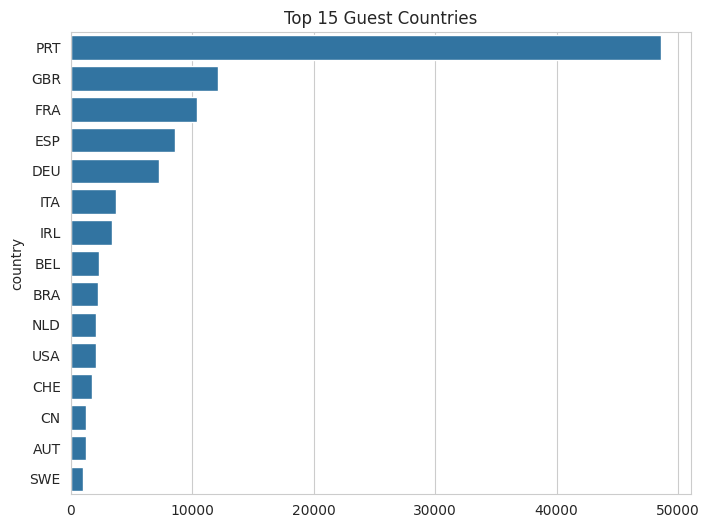

In [68]:
# country
print(hotel['country'].value_counts(dropna=False).head(15))
plt.figure(figsize=(8,6))
top_c = hotel['country'].value_counts().head(15)
sns.barplot(x=top_c.values, y=top_c.index)
plt.title('Top 15 Guest Countries')
plt.show()


market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: count, dtype: int64


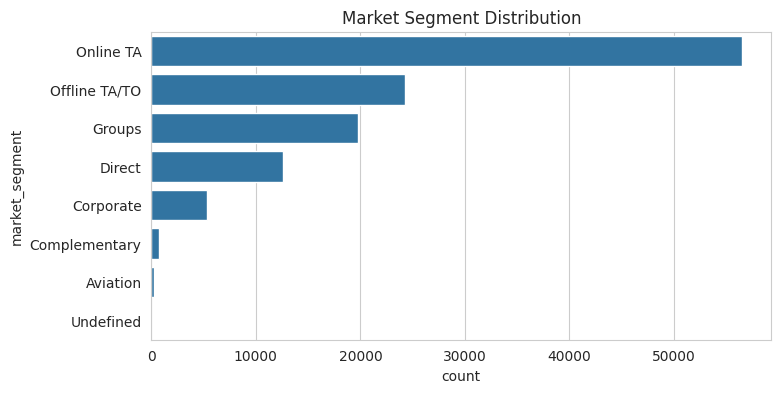

In [69]:
# market_segment
print(hotel['market_segment'].value_counts(dropna=False))
plt.figure(figsize=(8,4))
sns.countplot(data=hotel, y='market_segment', order=hotel['market_segment'].value_counts().index)
plt.title('Market Segment Distribution')
plt.show()


distribution_channel
TA/TO        97870
Direct       14645
Corporate     6677
GDS            193
Undefined        5
Name: count, dtype: int64


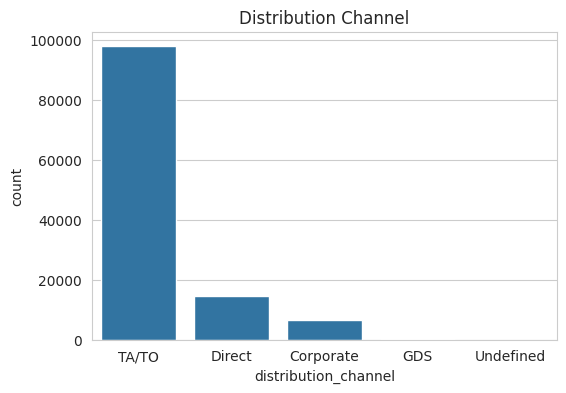

In [70]:
# distribution_channel
print(hotel['distribution_channel'].value_counts(dropna=False))
plt.figure(figsize=(6,4))
sns.countplot(data=hotel, x='distribution_channel', order=hotel['distribution_channel'].value_counts().index)
plt.title('Distribution Channel')
plt.show()


is_repeated_guest
0    115580
1      3810
Name: count, dtype: int64


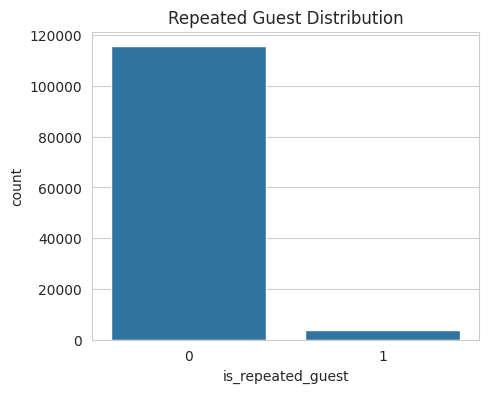

In [71]:
# is_repeated_guest
print(hotel['is_repeated_guest'].value_counts(dropna=False))
plt.figure(figsize=(5,4))
sns.countplot(data=hotel, x='is_repeated_guest')
plt.title('Repeated Guest Distribution')
plt.show()


count    119390.000000
mean          0.087118
std           0.844336
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          26.000000
Name: previous_cancellations, dtype: float64
count    119390.000000
mean          0.137097
std           1.497437
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          72.000000
Name: previous_bookings_not_canceled, dtype: float64


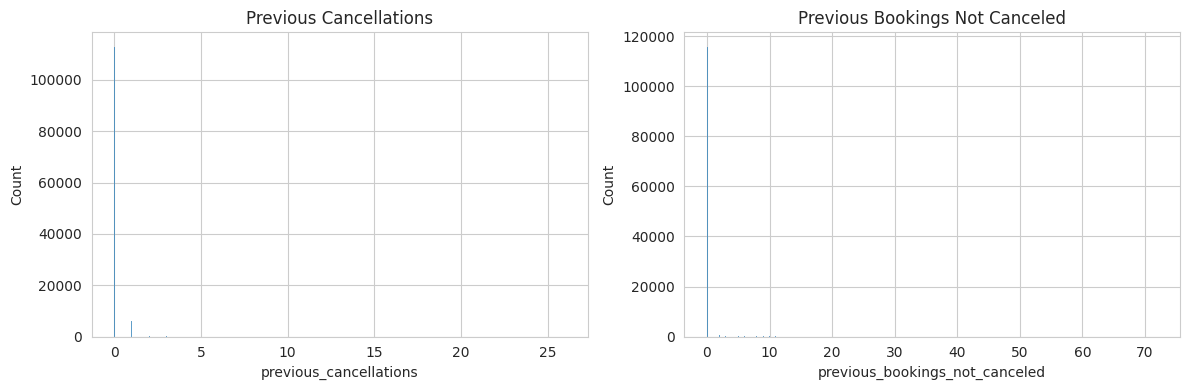

In [72]:
# previous_cancellations & previous_bookings_not_canceled
print(hotel['previous_cancellations'].describe())
print(hotel['previous_bookings_not_canceled'].describe())
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(hotel['previous_cancellations'], ax=axes[0]); axes[0].set_title('Previous Cancellations')
sns.histplot(hotel['previous_bookings_not_canceled'], ax=axes[1]); axes[1].set_title('Previous Bookings Not Canceled')
plt.tight_layout()
plt.show()


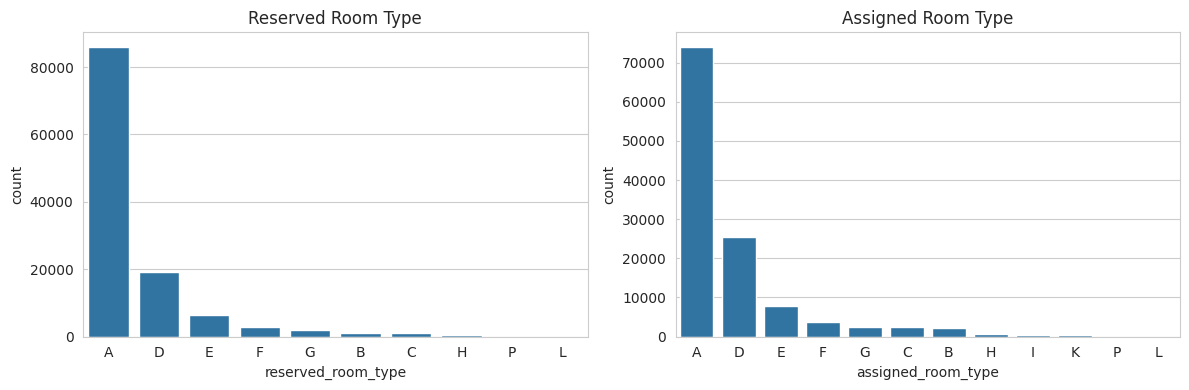

In [73]:
# reserved_room_type & assigned_room_type
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.countplot(data=hotel, x='reserved_room_type', order=hotel['reserved_room_type'].value_counts().index, ax=axes[0])
axes[0].set_title('Reserved Room Type')
sns.countplot(data=hotel, x='assigned_room_type', order=hotel['assigned_room_type'].value_counts().index, ax=axes[1])
axes[1].set_title('Assigned Room Type')
plt.tight_layout()
plt.show()


count    119390.000000
mean          0.221124
std           0.652306
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          21.000000
Name: booking_changes, dtype: float64


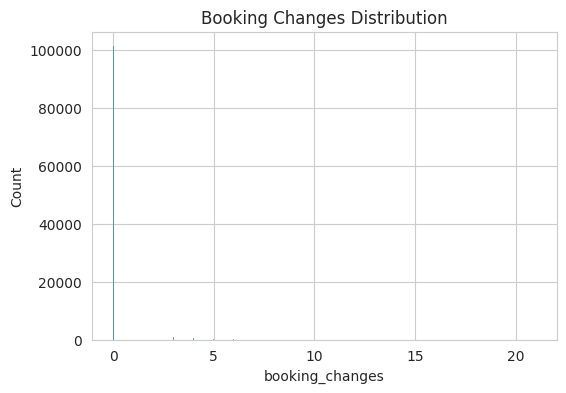

In [74]:
# booking_changes
print(hotel['booking_changes'].describe())
plt.figure(figsize=(6,4))
sns.histplot(hotel['booking_changes'])
plt.title('Booking Changes Distribution')
plt.show()


deposit_type
No Deposit    104641
Non Refund     14587
Refundable       162
Name: count, dtype: int64


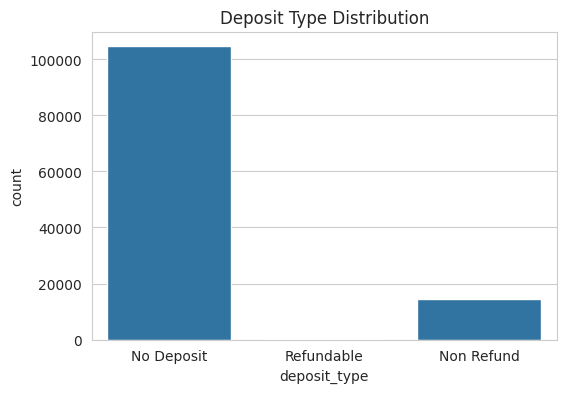

In [75]:
# deposit_type
print(hotel['deposit_type'].value_counts(dropna=False))
plt.figure(figsize=(6,4))
sns.countplot(data=hotel, x='deposit_type')
plt.title('Deposit Type Distribution')
plt.show()


Agent unique: 333 | missing: 16340
Company unique: 352 | missing: 112593


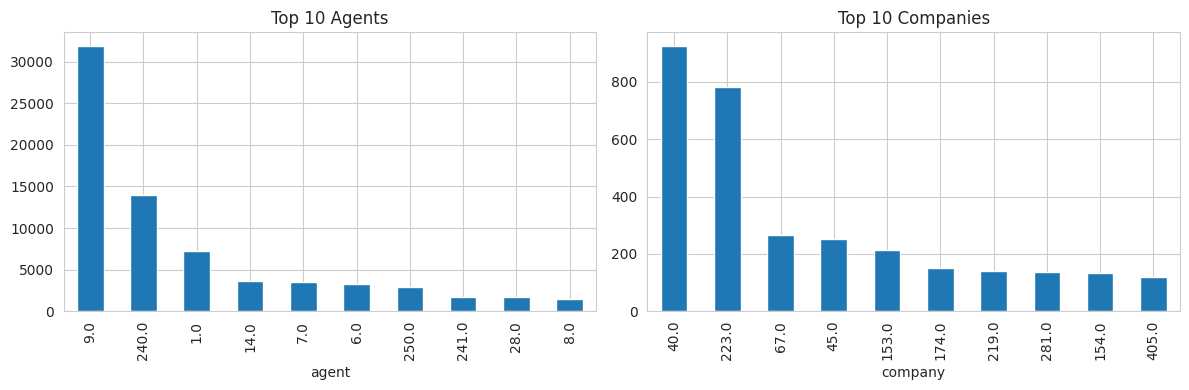

In [76]:
# agent & company (very high missingness expected)
print("Agent unique:", hotel['agent'].nunique(), "| missing:", hotel['agent'].isnull().sum())
print("Company unique:", hotel['company'].nunique(), "| missing:", hotel['company'].isnull().sum())
fig, axes = plt.subplots(1, 2, figsize=(12,4))
hotel['agent'].value_counts().head(10).plot(kind='bar', ax=axes[0], title='Top 10 Agents')
hotel['company'].value_counts().head(10).plot(kind='bar', ax=axes[1], title='Top 10 Companies')
plt.tight_layout()
plt.show()


count    119390.000000
mean          2.321149
std          17.594721
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         391.000000
Name: days_in_waiting_list, dtype: float64


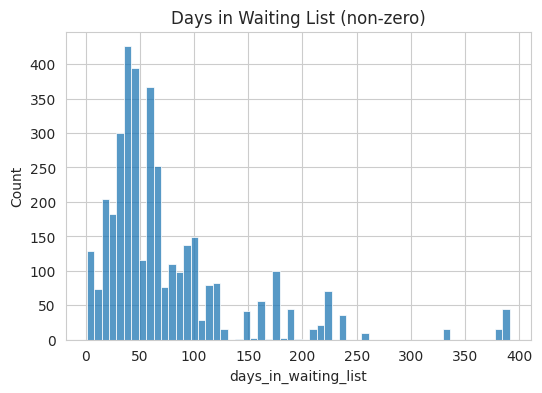

In [77]:
# days_in_waiting_list
print(hotel['days_in_waiting_list'].describe())
plt.figure(figsize=(6,4))
sns.histplot(hotel[hotel['days_in_waiting_list']>0]['days_in_waiting_list'])
plt.title('Days in Waiting List (non-zero)')
plt.show()


customer_type
Transient          89613
Transient-Party    25124
Contract            4076
Group                577
Name: count, dtype: int64


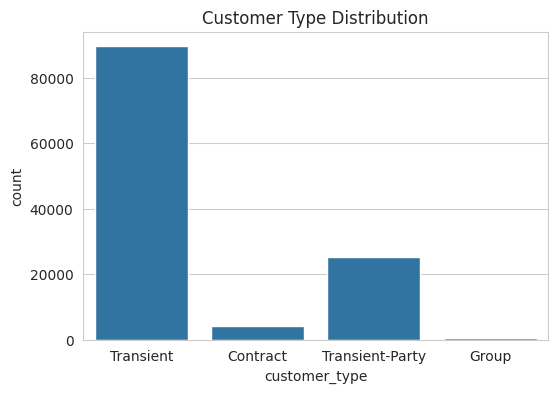

In [78]:
# customer_type
print(hotel['customer_type'].value_counts(dropna=False))
plt.figure(figsize=(6,4))
sns.countplot(data=hotel, x='customer_type')
plt.title('Customer Type Distribution')
plt.show()


count    119390.000000
mean        101.831122
std          50.535790
min          -6.380000
25%          69.290000
50%          94.575000
75%         126.000000
max        5400.000000
Name: adr, dtype: float64


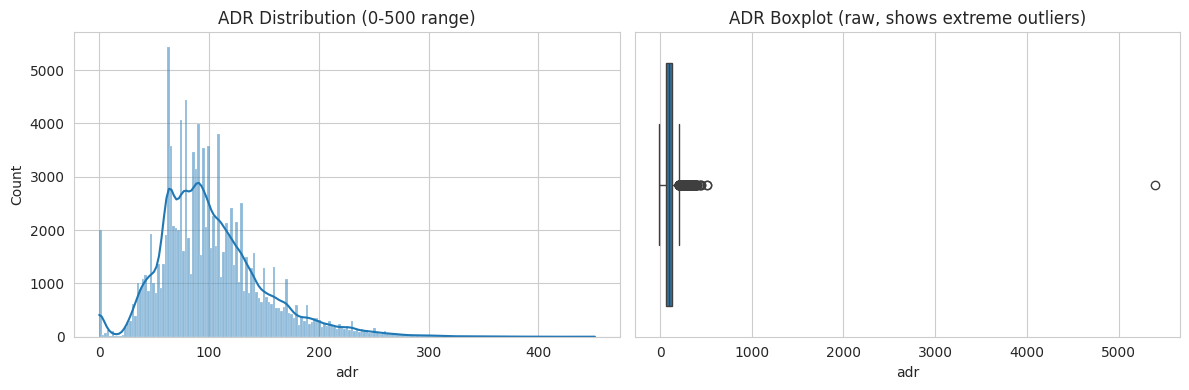

In [79]:
# adr (Average Daily Rate)
print(hotel['adr'].describe())
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(hotel[hotel['adr'].between(0, 500)]['adr'], kde=True, ax=axes[0])
axes[0].set_title('ADR Distribution (0-500 range)')
sns.boxplot(x=hotel['adr'], ax=axes[1])
axes[1].set_title('ADR Boxplot (raw, shows extreme outliers)')
plt.tight_layout()
plt.show()


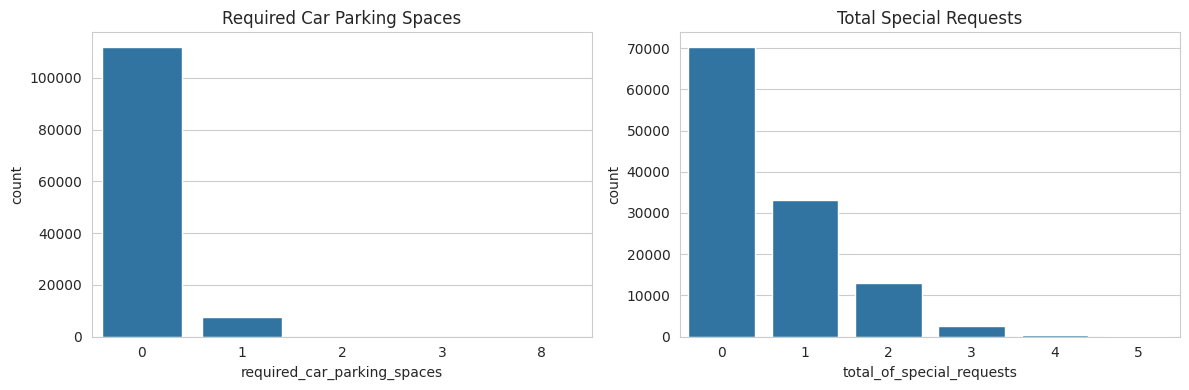

In [80]:
# required_car_parking_spaces & total_of_special_requests
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.countplot(x=hotel['required_car_parking_spaces'], ax=axes[0]); axes[0].set_title('Required Car Parking Spaces')
sns.countplot(x=hotel['total_of_special_requests'], ax=axes[1]); axes[1].set_title('Total Special Requests')
plt.tight_layout()
plt.show()


reservation_status
Check-Out    75166
Canceled     43017
No-Show       1207
Name: count, dtype: int64


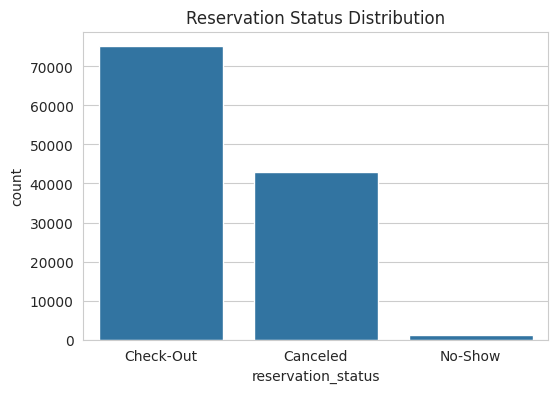


Reservation status date range: 2014-10-17 00:00:00 to 2017-09-14 00:00:00


In [81]:
# reservation_status & reservation_status_date
print(hotel['reservation_status'].value_counts(dropna=False))
plt.figure(figsize=(6,4))
sns.countplot(data=hotel, x='reservation_status')
plt.title('Reservation Status Distribution')
plt.show()

hotel['reservation_status_date'] = pd.to_datetime(hotel['reservation_status_date'], errors='coerce')
print("\nReservation status date range:", hotel['reservation_status_date'].min(), "to", hotel['reservation_status_date'].max())


In [82]:
# PII columns: name, email, phone-number, credit_card
print("Unique names:", hotel['name'].nunique())
print("Unique emails:", hotel['email'].nunique())
print("Unique phone numbers:", hotel['phone-number'].nunique())
print("Sample credit_card values:", hotel['credit_card'].dropna().unique()[:3])


Unique names: 81503
Unique emails: 115889
Unique phone numbers: 119390
Sample credit_card values: <StringArray>
['************4322', '************9157', '************3734']
Length: 3, dtype: str


## 3.4 Bivariate Analysis (relationship with `is_canceled`)

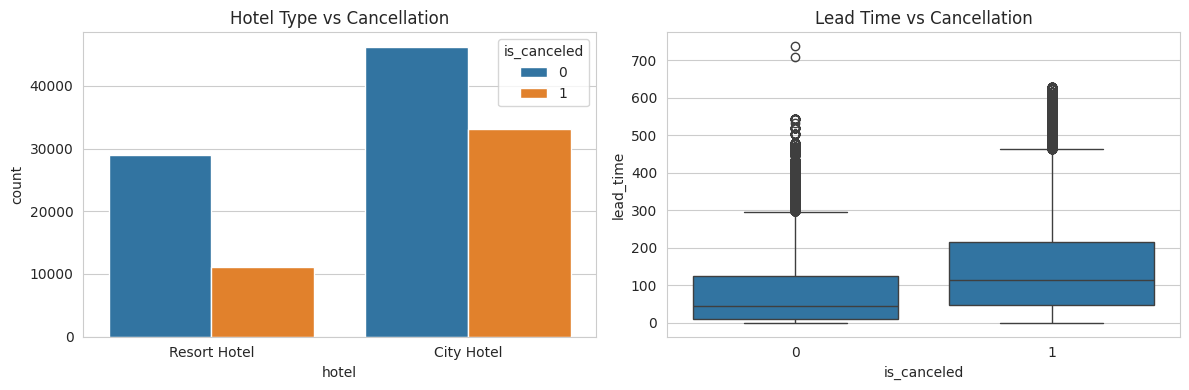

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.countplot(data=hotel, x='hotel', hue='is_canceled', ax=axes[0])
axes[0].set_title('Hotel Type vs Cancellation')
sns.boxplot(data=hotel, x='is_canceled', y='lead_time', ax=axes[1])
axes[1].set_title('Lead Time vs Cancellation')
plt.tight_layout()
plt.show()


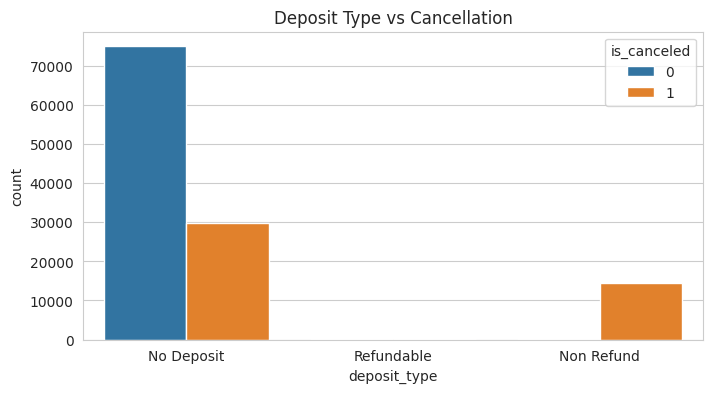

In [84]:
plt.figure(figsize=(8,4))
sns.countplot(data=hotel, x='deposit_type', hue='is_canceled')
plt.title('Deposit Type vs Cancellation')
plt.show()


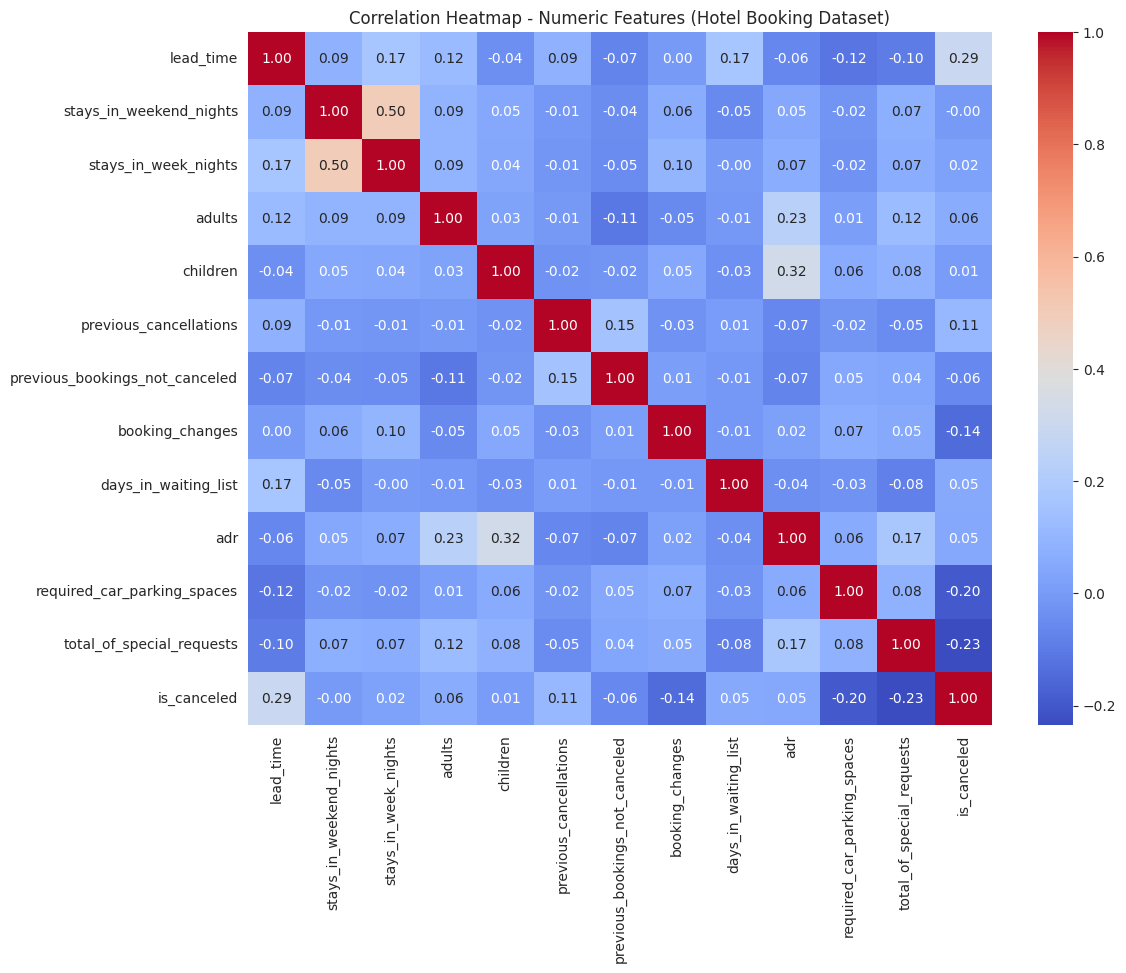

In [85]:
num_cols_hotel = ['lead_time','stays_in_weekend_nights','stays_in_week_nights','adults','children',
                  'previous_cancellations','previous_bookings_not_canceled','booking_changes',
                  'days_in_waiting_list','adr','required_car_parking_spaces','total_of_special_requests','is_canceled']
plt.figure(figsize=(12,9))
sns.heatmap(hotel[num_cols_hotel].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - Numeric Features (Hotel Booking Dataset)')
plt.show()


## 3.5 Data Cleaning

Cleaning steps performed:
1. **company** — extremely high missing % (~94%) → drop the column entirely (not useful).
2. **agent** — moderate missingness → fill with 0 (meaning "no agent / direct booking"), since it is an ID-like numeric column.
3. **country** — small missingness → fill with the **mode** (most common country).
4. **children** — very small missingness (4 rows) → fill with **0** (most common value / logical default).
5. **PII columns (name, email, phone-number, credit_card)** — dropped for privacy reasons; they carry no analytical value and are sensitive personal data.
6. **adr** — remove the single extreme outlier row (adr > 5000, clearly a data entry error) and cap remaining outliers using IQR.
7. Convert **reservation_status_date** to datetime (already done above).
8. Drop duplicate rows.
9. Fix illogical rows: bookings with **0 adults, 0 children, and 0 babies** (no guests at all) are removed as invalid records.


In [86]:
hotel_clean = hotel.copy()

# 1. Drop 'company' - too many missing values
hotel_clean = hotel_clean.drop(columns=['company'])

# 2. agent -> fill missing with 0 (no agent)
hotel_clean['agent'] = hotel_clean['agent'].fillna(0)

# 3. country -> fill missing with mode
hotel_clean['country'] = hotel_clean['country'].fillna(hotel_clean['country'].mode()[0])

# 4. children -> fill missing with 0
hotel_clean['children'] = hotel_clean['children'].fillna(0)

# 5. Drop PII columns
hotel_clean = hotel_clean.drop(columns=['name', 'email', 'phone-number', 'credit_card'])

# 6. Remove extreme adr outlier(s) and cap remaining with IQR
hotel_clean = hotel_clean[hotel_clean['adr'] < 5000]
Q1 = hotel_clean['adr'].quantile(0.25)
Q3 = hotel_clean['adr'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
lower = max(lower, 0)
hotel_clean['adr'] = hotel_clean['adr'].clip(lower, upper)

# 7. Drop duplicate rows
before = len(hotel_clean)
hotel_clean = hotel_clean.drop_duplicates()
print(f"Dropped {before - len(hotel_clean)} duplicate rows")

# 8. Remove rows with zero total guests (invalid bookings)
before = len(hotel_clean)
hotel_clean = hotel_clean[(hotel_clean['adults'] + hotel_clean['children'] + hotel_clean['babies']) > 0]
print(f"Dropped {before - len(hotel_clean)} rows with zero total guests")

print("\nMissing values after cleaning:")
print(hotel_clean.isnull().sum())


Dropped 32038 duplicate rows
Dropped 166 rows with zero total guests

Missing values after cleaning:
hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
days_in_waiting_list              0

In [87]:
hotel_clean.info()
hotel_clean.head()


<class 'pandas.DataFrame'>
Index: 87185 entries, 0 to 119389
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   hotel                           87185 non-null  str           
 1   is_canceled                     87185 non-null  int64         
 2   lead_time                       87185 non-null  int64         
 3   arrival_date_year               87185 non-null  int64         
 4   arrival_date_month              87185 non-null  str           
 5   arrival_date_week_number        87185 non-null  int64         
 6   arrival_date_day_of_month       87185 non-null  int64         
 7   stays_in_weekend_nights         87185 non-null  int64         
 8   stays_in_week_nights            87185 non-null  int64         
 9   adults                          87185 non-null  int64         
 10  children                        87185 non-null  float64       
 11  babies           

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [88]:
hotel_clean.to_csv('data/hotel_booking_cleaned.csv', index=False)
print("Saved cleaned Hotel Booking dataset -> data/hotel_booking_cleaned.csv")


Saved cleaned Hotel Booking dataset -> data/hotel_booking_cleaned.csv


---
# 4. Summary

| Dataset | Original Shape | Cleaned Shape | Key Cleaning Actions |
|---|---|---|---|
| Loan | (614, 13) | See output above | Filled missing categorical (mode) & numeric (median) values, fixed `Dependents`, capped outliers (IQR) |
| Adult | (48842, 15) | See output above | Replaced `'?'` with NaN, filled missing categorical values with mode, stripped whitespace, dropped duplicates |
| Hotel Booking | (119390, 32) | See output above | Dropped `company` & PII columns, filled `agent`/`country`/`children`, removed adr outliers & invalid zero-guest bookings, dropped duplicates |

All three datasets have been fully explored (every column analyzed and visualized) and cleaned. The cleaned CSV files have been saved into the `data/` folder for further modeling work.
